In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
from datetime import datetime, timedelta
import pandas as pd


class MBESAnalyzer:
    """Complete MBES bathymetry analysis class - keeps everything organized."""

    def __init__(
        self, file_path, origin=(60.8011575, 10.7122345, 0), nodata_value=9999
    ):
        """Initialize with your MBES file."""
        self.file_path = file_path
        self.origin = origin
        self.nodata_value = nodata_value

        # Data containers
        self.data = None
        self.data_clean = None
        self.extent = None
        self.resolution = None
        self.centerline = None
        self.crs = None

        # Load data immediately
        self._load_data()

    def _load_data(self):
        """Internal method to load and process MBES data."""
        print("🔍 Loading MBES data...")

        # Load from file
        with rasterio.open(self.file_path) as src:
            self.data = src.read(1)
            self.crs = src.crs
            bounds = src.bounds

        # Clean nodata
        self.data_clean = np.where(self.data == self.nodata_value, np.nan, self.data)

        # Convert to local coordinates
        lat0, lon0, h0 = self.origin
        if self.crs.to_string() == "EPSG:4326" or "EPSG:4326" in str(self.crs):
            x_local_min = (bounds.left - lon0) * 111319.9 * np.cos(np.radians(lat0))
            x_local_max = (bounds.right - lon0) * 111319.9 * np.cos(np.radians(lat0))
            y_local_min = (bounds.bottom - lat0) * 110540.0
            y_local_max = (bounds.top - lat0) * 110540.0
        else:
            transformer = Transformer.from_crs(self.crs, "EPSG:4326", always_xy=True)
            corners_x = [bounds.left, bounds.right, bounds.left, bounds.right]
            corners_y = [bounds.bottom, bounds.bottom, bounds.top, bounds.top]
            lon_corners, lat_corners = transformer.transform(corners_x, corners_y)
            x_local_corners = [
                (lon - lon0) * 111319.9 * np.cos(np.radians(lat0))
                for lon in lon_corners
            ]
            y_local_corners = [(lat - lat0) * 110540.0 for lat in lat_corners]
            x_local_min, x_local_max = min(x_local_corners), max(x_local_corners)
            y_local_min, y_local_max = min(y_local_corners), max(y_local_corners)

        self.extent = [x_local_min, x_local_max, y_local_min, y_local_max]
        height, width = self.data_clean.shape
        self.resolution = (self.extent[1] - self.extent[0]) / width

    def print_overview(self):
        """Print comprehensive data overview."""
        print("\n=== MBES DATA OVERVIEW ===")
        print(f"File: {self.file_path}")
        print(f"Origin: {self.origin[0]:.6f}°N, {self.origin[1]:.6f}°E")
        print(f"Shape: {self.data_clean.shape}")
        print(f"Resolution: {self.resolution:.3f}m ({self.resolution*100:.1f}cm/pixel)")
        print(
            f"Data range: {np.nanmin(self.data_clean):.2f} to {np.nanmax(self.data_clean):.2f}m"
        )
        print(
            f"NoData: {np.sum(np.isnan(self.data_clean))/self.data_clean.size*100:.1f}%"
        )

    def plot_bathymetry(self):
        """Plot basic 2D bathymetry map."""
        fig, ax = plt.subplots(figsize=(8, 5))  # Changed from (12, 8)
        im = ax.imshow(
            self.data_clean, extent=self.extent, cmap="terrain", origin="upper"
        )
        plt.colorbar(im, label="Depth/Elevation (m)")
        plt.title("MBES Swath Bathymetry")
        plt.xlabel(f"East (m) from {self.origin[0]:.6f}°, {self.origin[1]:.6f}°")
        plt.ylabel("North (m)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def extract_centerline(self, start_time="11:58:20", end_time="12:12:36"):
        """Extract vehicle centerline from swath data."""
        start_dt = datetime.strptime(start_time, "%H:%M:%S")
        end_dt = datetime.strptime(end_time, "%H:%M:%S")
        duration = (end_dt - start_dt).total_seconds() / 60

        height, width = self.data_clean.shape
        centerline_data = []

        for row_idx in range(height):
            row_data = self.data_clean[row_idx, :]
            valid_indices = np.where(~np.isnan(row_data))[0]

            if len(valid_indices) > 0:
                left_edge = valid_indices[0]
                right_edge = valid_indices[-1]
                center_col = (left_edge + right_edge) // 2
                center_depth = (
                    row_data[center_col]
                    if not np.isnan(row_data[center_col])
                    else np.nanmean(
                        row_data[max(0, center_col - 2) : min(width, center_col + 3)]
                    )
                )

                centerline_data.append(
                    {
                        "center_col": center_col,
                        "depth": center_depth,
                        "left_edge": left_edge,
                        "right_edge": right_edge,
                        "swath_width": right_edge - left_edge,
                    }
                )
            else:
                centerline_data.append(
                    {
                        "center_col": width // 2,
                        "depth": np.nan,
                        "left_edge": np.nan,
                        "right_edge": np.nan,
                        "swath_width": 0,
                    }
                )

        center_cols = np.array([row["center_col"] for row in centerline_data])
        depths = np.array([row["depth"] for row in centerline_data])

        y_coords = np.linspace(self.extent[3], self.extent[2], height)
        x_coords = self.extent[0] + (self.extent[1] - self.extent[0]) * (
            center_cols / width
        )
        time_array = np.linspace(0, duration, height)

        self.centerline = {
            "x_coords": x_coords,
            "y_coords": y_coords,
            "depths": depths,
            "time_minutes": time_array,
            "swath_data": centerline_data,
        }

        print(
            f"✅ Centerline extracted: {len(x_coords)} points over {duration:.1f} minutes"
        )
        return self.centerline

    def plot_centerline_track(self):
        """Plot bathymetry with vehicle centerline overlay."""
        if self.centerline is None:
            print("❌ No centerline data. Run extract_centerline() first.")
            return

        height, width = self.data_clean.shape
        fig, ax = plt.subplots(figsize=(8, 5))  # Changed from (12, 8)
        im = ax.imshow(
            self.data_clean,
            extent=self.extent,
            cmap="terrain",
            origin="upper",
            alpha=0.8,
        )
        ax.plot(
            self.centerline["x_coords"],
            self.centerline["y_coords"],
            "red",
            linewidth=3,
            label="Vehicle Track",
        )

        # Show sample swath edges
        for i in range(0, height, height // 20):
            row_data = self.data_clean[i, :]
            valid_indices = np.where(~np.isnan(row_data))[0]
            if len(valid_indices) > 0:
                left_col, right_col = valid_indices[0], valid_indices[-1]
                left_x = self.extent[0] + (self.extent[1] - self.extent[0]) * (
                    left_col / width
                )
                right_x = self.extent[0] + (self.extent[1] - self.extent[0]) * (
                    right_col / width
                )
                y_pos = self.extent[3] - (self.extent[3] - self.extent[2]) * (
                    i / height
                )
                ax.plot(
                    [left_x, right_x], [y_pos, y_pos], "yellow", alpha=0.3, linewidth=1
                )

        ax.set_title("MBES with Vehicle Centerline")
        ax.set_xlabel(f"East (m) from {self.origin[0]:.6f}°, {self.origin[1]:.6f}°")
        ax.set_ylabel("North (m)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_depth_profile(self):
        """Plot vehicle depth profile over time."""
        if self.centerline is None:
            print("❌ No centerline data. Run extract_centerline() first.")
            return

        fig, ax = plt.subplots(figsize=(7, 4))  # Changed from (10, 6)
        ax.plot(
            self.centerline["time_minutes"],
            self.centerline["depths"],
            "blue",
            linewidth=2,
        )
        ax.set_title("Vehicle Track Depth Profile")
        ax.set_xlabel("Time (minutes from start)")
        ax.set_ylabel("Depth/Elevation (m)")
        ax.grid(True, alpha=0.3)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()

    def plot_swath_width(self):
        """Plot swath width variation over time."""
        if self.centerline is None:
            print("❌ No centerline data. Run extract_centerline() first.")
            return

        swath_widths = [
            row["swath_width"] * self.resolution
            for row in self.centerline["swath_data"]
        ]
        fig, ax = plt.subplots(figsize=(7, 4))  # Changed from (10, 6)
        ax.plot(self.centerline["time_minutes"], swath_widths, "green", linewidth=2)
        ax.set_title("MBES Swath Width Over Time")
        ax.set_xlabel("Time (minutes from start)")
        ax.set_ylabel("Swath Width (m)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def export_centerline(self, filename="mbes_centerline.csv"):
        """Export centerline data to CSV."""
        if self.centerline is None:
            print("❌ No centerline data. Run extract_centerline() first.")
            return

        df = pd.DataFrame(
            {
                "time_minutes": self.centerline["time_minutes"],
                "east_m": self.centerline["x_coords"],
                "north_m": self.centerline["y_coords"],
                "depth_m": self.centerline["depths"],
            }
        )

        df_clean = df.dropna()
        df_clean.to_csv(filename, index=False)
        print(f"✅ Exported {len(df_clean)} points to: {filename}")
        return df_clean

In [3]:
# mbes_flatten_viz.py  (fixed, memory-safe)
from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from typing import Literal, Optional, Tuple, Dict
import matplotlib.pyplot as plt

try:
    import rasterio
except Exception:
    rasterio = None

try:
    from scipy.ndimage import gaussian_filter
except Exception:
    gaussian_filter = None


# ---------------------- helpers ----------------------


def _xy_from_affine(transform, rows, cols):
    """
    Pixel-center XY from rasterio Affine (vectorized for grids/blocks).
    rows, cols can be 2D grids (meshgrid with indexing='ij').
    """
    a, b, c, d, e, f = (
        transform.a,
        transform.b,
        transform.c,
        transform.d,
        transform.e,
        transform.f,
    )
    x = c + a * cols + b * rows + 0.5 * (a + b)
    y = f + d * cols + e * rows + 0.5 * (d + e)
    return x, y


def _poly_design(x, y, order: int) -> Tuple[np.ndarray, Dict]:
    """Build polynomial design up to 'order' with normalization for stability."""
    x0, y0 = float(np.nanmean(x)), float(np.nanmean(y))
    sx = float(np.nanstd(x)) or 1.0
    sy = float(np.nanstd(y)) or 1.0
    X = (x - x0) / sx
    Y = (y - y0) / sy

    if order == 1:
        terms = [np.ones_like(X), X, Y]
    elif order == 2:
        terms = [np.ones_like(X), X, Y, X**2, X * Y, Y**2]
    elif order == 3:
        terms = [
            np.ones_like(X),
            X,
            Y,
            X**2,
            X * Y,
            Y**2,
            X**3,
            (X**2) * Y,
            X * (Y**2),
            Y**3,
        ]
    else:
        raise ValueError("poly_order must be 1, 2, or 3")

    A = np.stack(terms, axis=1)
    scale = dict(x0=x0, y0=y0, sx=sx, sy=sy, order=order)
    return A, scale


def _poly_eval_grid(
    coeffs_f32: np.ndarray, transform, H, W, scale: Dict, chunk_rows: int = 256
) -> np.ndarray:
    """
    Evaluate fitted polynomial on the full grid in chunks (memory-friendly).
    Uses float32 throughout to keep memory low.
    """
    trend = np.full((H, W), np.nan, dtype=np.float32)
    a, b, c, d, e, f = (
        transform.a,
        transform.b,
        transform.c,
        transform.d,
        transform.e,
        transform.f,
    )

    cols = np.arange(W, dtype=np.float32)[None, :]  # (1, W)
    for r0 in range(0, H, chunk_rows):
        r1 = min(r0 + chunk_rows, H)
        rows_block = np.arange(r0, r1, dtype=np.float32)[:, None]  # (R,1)

        # Pixel-center XY for this block (float32)
        x = (c + a * cols + b * rows_block + 0.5 * (a + b)).astype(np.float32)
        y = (f + d * cols + e * rows_block + 0.5 * (d + e)).astype(np.float32)

        # Normalize
        X = (x - np.float32(scale["x0"])) / np.float32(scale["sx"] or 1.0)
        Y = (y - np.float32(scale["y0"])) / np.float32(scale["sy"] or 1.0)

        o = scale["order"]
        if o == 1:
            tstack = np.stack([np.ones_like(X), X, Y], axis=-1).astype(np.float32)
        elif o == 2:
            tstack = np.stack(
                [np.ones_like(X), X, Y, X**2, X * Y, Y**2], axis=-1
            ).astype(np.float32)
        else:
            tstack = np.stack(
                [
                    np.ones_like(X),
                    X,
                    Y,
                    X**2,
                    X * Y,
                    Y**2,
                    X**3,
                    (X**2) * Y,
                    X * (Y**2),
                    Y**3,
                ],
                axis=-1,
            ).astype(np.float32)

        # tensordot -> (R,W)
        trend[r0:r1, :] = np.tensordot(tstack, coeffs_f32, axes=([-1], [0])).astype(
            np.float32
        )

    return trend


def _huber_weights(resid, delta=1.5):
    a = np.abs(resid) <= delta
    w = np.empty_like(resid)
    w[a] = 1.0
    w[~a] = delta / (np.abs(resid[~a]) + 1e-12)
    return w


def _robust_poly_fit(x, y, z, order: int, iters: int = 4, max_points: int = 300_000):
    """
    Robust polynomial fit z ~ f(x,y). Operates in float64 for stability.
    Downsamples to max_points to control memory/time.
    """
    n = len(z)
    if n == 0:
        raise ValueError("No valid samples for polynomial fit.")
    if n > max_points:
        idx = np.random.default_rng(0).choice(n, size=max_points, replace=False)
        x, y, z = x[idx], y[idx], z[idx]

    x = x.astype(np.float64, copy=False)
    y = y.astype(np.float64, copy=False)
    z = z.astype(np.float64, copy=False)

    A, scale = _poly_design(x, y, order)
    coeffs, *_ = np.linalg.lstsq(A, z, rcond=None)

    for _ in range(iters):
        r = z - A @ coeffs
        mad = np.median(np.abs(r - np.median(r))) + 1e-9
        w = _huber_weights(r / (1.4826 * mad), delta=1.5)
        Aw = A * w[:, None]
        zw = z * w
        coeffs, *_ = np.linalg.lstsq(Aw, zw, rcond=None)

    return coeffs, scale


def _nan_gaussian(data: np.ndarray, sigma_y: float, sigma_x: float) -> np.ndarray:
    """NaN-aware Gaussian smoothing via weight normalization (float32)."""
    if gaussian_filter is None:
        raise ImportError("scipy is required for gaussian detrend: pip install scipy")
    nan_mask = ~np.isfinite(data)
    base = data.copy()
    base[nan_mask] = 0.0
    w = np.ones_like(data, dtype=np.float32)
    w[nan_mask] = 0.0
    smooth = gaussian_filter(base, sigma=(sigma_y, sigma_x), mode="nearest")
    w_smooth = gaussian_filter(w, sigma=(sigma_y, sigma_x), mode="nearest")
    with np.errstate(invalid="ignore", divide="ignore"):
        smooth = smooth / w_smooth
    smooth[w_smooth == 0] = np.nan
    return smooth.astype(np.float32)


# ---------------------- main detrend ----------------------


def detrend_bathymetry(
    elevation_data: np.ndarray,
    transform,
    mode: Literal["poly", "gauss"] = "poly",
    poly_order: int = 2,
    robust_iters: int = 4,
    max_fit_points: int = 300_000,
    gauss_sigma_m: float = 10.0,
    eval_chunk_rows: int = 256,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (residuals, trend). Uses float32 for large arrays.
    """
    # keep big arrays in float32
    z = elevation_data.astype(np.float32, copy=False)
    H, W = z.shape
    valid = np.isfinite(z)

    if mode == "poly":
        # Get valid sample coordinates (1D!) — NO broadcasting
        rows, cols = np.where(valid)

        # Convert pixel indices to XY meters at pixel centers (1D)
        a, b, c, d, e, f = (
            transform.a,
            transform.b,
            transform.c,
            transform.d,
            transform.e,
            transform.f,
        )
        rows_f = rows.astype(np.float64)
        cols_f = cols.astype(np.float64)
        x = c + a * cols_f + b * rows_f + 0.5 * (a + b)
        y = f + d * cols_f + e * rows_f + 0.5 * (d + e)

        z_samples = z[rows, cols].astype(np.float64)

        coeffs64, scale = _robust_poly_fit(
            x,
            y,
            z_samples,
            order=poly_order,
            iters=robust_iters,
            max_points=max_fit_points,
        )

        # Evaluate on the full grid in float32 chunks
        coeffs32 = coeffs64.astype(np.float32)
        trend = _poly_eval_grid(
            coeffs32, transform, H, W, scale, chunk_rows=eval_chunk_rows
        )

        residuals = (z - trend).astype(np.float32)
        residuals[~valid] = np.nan
        trend[~valid] = np.nan
        return residuals, trend

    elif mode == "gauss":
        # convert desired sigma (meters) → pixels
        dx = abs(getattr(transform, "a", 1.0)) or 1.0
        dy = abs(getattr(transform, "e", 1.0)) or 1.0
        sigma_x = max(gauss_sigma_m / dx, 0.1)
        sigma_y = max(gauss_sigma_m / dy, 0.1)
        trend = _nan_gaussian(z, sigma_y=float(sigma_y), sigma_x=float(sigma_x))
        residuals = (z - trend).astype(np.float32)
        return residuals, trend

    else:
        raise ValueError("mode must be 'poly' or 'gauss'")


def save_residual_geotiff(
    out_path: str,
    residuals: np.ndarray,
    reference_path: Optional[str] = None,
    transform=None,
    crs=None,
    nodata_value: float = np.nan,
):
    """Save residuals to GeoTIFF."""
    if rasterio is None:
        raise ImportError("rasterio is required to save GeoTIFFs: pip install rasterio")

    data = residuals.astype("float32", copy=False)

    if reference_path is not None:
        with rasterio.open(reference_path) as src:
            profile = src.profile
            profile.update(count=1, dtype="float32", compress="deflate")
            if not np.isnan(nodata_value):
                profile.update(nodata=nodata_value)
            with rasterio.open(out_path, "w", **profile) as dst:
                if np.isnan(nodata_value):
                    mask = ~np.isfinite(data)
                    data = np.nan_to_num(data, nan=0.0)
                    dst.write(data, 1)
                    dst.write_mask((~mask).astype("uint8") * 255)
                else:
                    data = np.where(np.isfinite(data), data, nodata_value).astype(
                        "float32"
                    )
                    dst.write(data, 1)
    else:
        if transform is None or crs is None:
            raise ValueError("Provide reference_path OR (transform and crs).")
        H, W = data.shape
        profile = dict(
            driver="GTiff",
            height=H,
            width=W,
            count=1,
            dtype="float32",
            crs=crs,
            transform=transform,
            compress="deflate",
        )
        if not np.isnan(nodata_value):
            profile["nodata"] = nodata_value
        with rasterio.open(out_path, "w", **profile) as dst:
            if np.isnan(nodata_value):
                mask = ~np.isfinite(data)
                data = np.nan_to_num(data, nan=0.0)
                dst.write(data, 1)
                dst.write_mask((~mask).astype("uint8") * 255)
            else:
                data = np.where(np.isfinite(data), data, nodata_value).astype("float32")
                dst.write(data, 1)


# ---------------------- convenience class ----------------------


@dataclass
class MBESDetrender:
    path: str
    nodata_value: Optional[float] = None  # if None, use raster's nodata

    # Filled by load()
    data: Optional[np.ndarray] = None
    transform: Optional[object] = None
    crs: Optional[object] = None
    bounds: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = (
        None  # (left, right, bottom, top)
    )

    # Results
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None
    meta: Optional[dict] = None  # stores mode and params

    def load(self):
        if rasterio is None:
            raise ImportError("rasterio is required: pip install rasterio")
        with rasterio.open(self.path) as src:
            z = src.read(1)
            self.transform = src.transform
            self.crs = src.crs
            self.bounds = src.bounds
            self.extent = (
                self.bounds.left,
                self.bounds.right,
                self.bounds.bottom,
                self.bounds.top,
            )
            nd = src.nodata if self.nodata_value is None else self.nodata_value
        # to float32 + NaN clean
        z = z.astype(np.float32, copy=False)
        if nd is not None and np.isfinite(nd):
            z[z == nd] = np.nan
        self.data = z
        return self

    def detrend(
        self,
        mode: Literal["poly", "gauss"] = "poly",
        poly_order: int = 2,
        robust_iters: int = 4,
        max_fit_points: int = 300_000,
        gauss_sigma_m: float = 10.0,
        eval_chunk_rows: int = 256,
    ):
        if self.data is None:
            self.load()
        residuals, trend = detrend_bathymetry(
            self.data,
            self.transform,
            mode=mode,
            poly_order=poly_order,
            robust_iters=robust_iters,
            max_fit_points=max_fit_points,
            gauss_sigma_m=gauss_sigma_m,
            eval_chunk_rows=eval_chunk_rows,
        )
        self.residuals = residuals
        self.trend = trend
        self.meta = dict(
            mode=mode,
            poly_order=poly_order,
            gauss_sigma_m=gauss_sigma_m,
            robust_iters=robust_iters,
            max_fit_points=max_fit_points,
            eval_chunk_rows=eval_chunk_rows,
        )
        return self

    # ------------- plotting -------------

    def _auto_vlim(self, arr: np.ndarray, pct: float = 99.0) -> float:
        a = np.abs(arr[np.isfinite(arr)])
        if a.size == 0:
            return 1.0
        return float(np.percentile(a, pct))

    def plot_original(self, figsize=(7, 6), cmap="terrain"):
        if self.data is None:
            self.load()
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(self.data, extent=self.extent, origin="upper", cmap=cmap)
        plt.colorbar(im, ax=ax, label="Depth / elevation (m)")
        ax.set_aspect("equal")
        ax.set_title("Original MBES bathymetry")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.tight_layout()
        return fig, ax

    def plot_trend(self, figsize=(7, 6), cmap="terrain"):
        if self.trend is None:
            raise RuntimeError("Run .detrend(...) first to compute trend.")
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(self.trend, extent=self.extent, origin="upper", cmap=cmap)
        plt.colorbar(im, ax=ax, label="Trend (m)")
        ax.set_aspect("equal")
        mode = self.meta.get("mode") if self.meta else "poly"
        subtitle = f"({mode}"
        if mode == "poly":
            subtitle += f", order={self.meta.get('poly_order', 2)})"
        else:
            subtitle += f", σ≈{self.meta.get('gauss_sigma_m', 10.0)} m)"
        ax.set_title("Estimated large-scale trend\n" + subtitle)
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.tight_layout()
        return fig, ax

    def plot_residuals(
        self, figsize=(7, 6), cmap="RdBu_r", vlim: Optional[float] = None
    ):
        if self.residuals is None:
            raise RuntimeError("Run .detrend(...) first to compute residuals.")
        if vlim is None:
            vlim = self._auto_vlim(self.residuals, pct=99.0)
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(
            self.residuals,
            extent=self.extent,
            origin="upper",
            cmap=cmap,
            vmin=-vlim,
            vmax=+vlim,
        )
        plt.colorbar(im, ax=ax, label="Residual (m)")
        ax.set_aspect("equal")
        ax.set_title("Detrended (local variations only)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.tight_layout()
        return fig, ax

    def plot_triptych(
        self,
        figsize=(18, 6),
        cmap_orig="terrain",
        cmap_trend="terrain",
        cmap_resid="RdBu_r",
        vlim_resid: Optional[float] = None,
        save_path: Optional[str] = None,
        dpi: int = 150,
    ):
        if self.data is None:
            self.load()
        if self.trend is None or self.residuals is None:
            raise RuntimeError("Run .detrend(...) first to compute trend/residuals.")
        if vlim_resid is None:
            vlim_resid = self._auto_vlim(self.residuals, pct=99.0)

        fig, axes = plt.subplots(1, 3, figsize=figsize)

        im0 = axes[0].imshow(
            self.data, extent=self.extent, origin="upper", cmap=cmap_orig
        )
        axes[0].set_title("Original")
        axes[0].set_aspect("equal")
        axes[0].set_xlabel("Easting (m)")
        axes[0].set_ylabel("Northing (m)")
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="m")

        im1 = axes[1].imshow(
            self.trend, extent=self.extent, origin="upper", cmap=cmap_trend
        )
        mode = self.meta.get("mode") if self.meta else "poly"
        subtitle = f"{mode}"
        if mode == "poly":
            subtitle += f" (order {self.meta.get('poly_order', 2)})"
        else:
            subtitle += f" (σ≈{self.meta.get('gauss_sigma_m', 10.0)} m)"
        axes[1].set_title(f"Estimated trend\n{subtitle}")
        axes[1].set_aspect("equal")
        axes[1].set_xlabel("Easting (m)")
        axes[1].set_ylabel("Northing (m)")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="m")

        im2 = axes[2].imshow(
            self.residuals,
            extent=self.extent,
            origin="upper",
            cmap=cmap_resid,
            vmin=-vlim_resid,
            vmax=+vlim_resid,
        )
        axes[2].set_title("Residuals (local variations)")
        axes[2].set_aspect("equal")
        axes[2].set_xlabel("Easting (m)")
        axes[2].set_ylabel("Northing (m)")
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="m")

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        return fig, axes

    def save_residual_geotiff(self, out_path: str, nodata_value: float = np.nan):
        if self.residuals is None:
            raise RuntimeError("Run .detrend(...) first.")
        save_residual_geotiff(
            out_path,
            self.residuals,
            reference_path=self.path,
            nodata_value=nodata_value,
        )

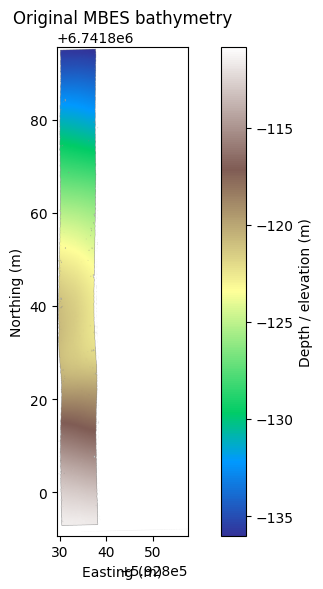

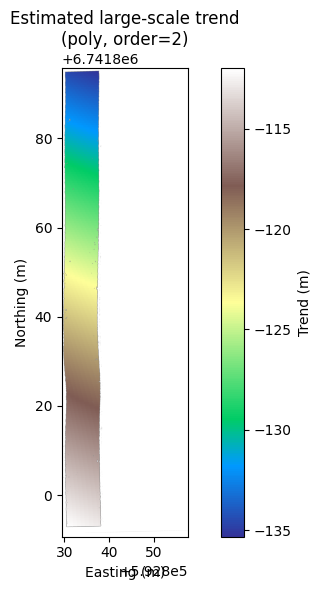

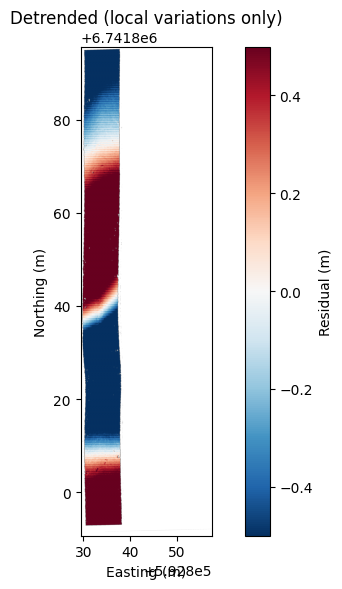

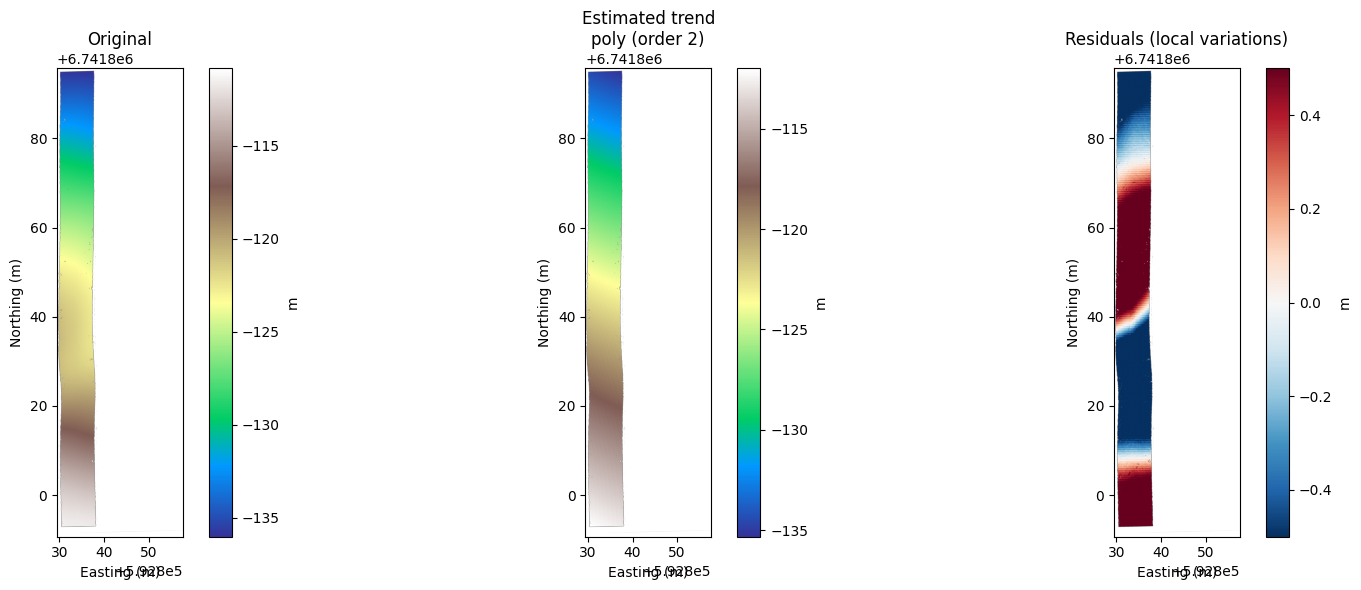

In [9]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# Option A: 2D polynomial (good default), with small chunks to save RAM
mb.detrend(mode="poly", poly_order=2, eval_chunk_rows=256, max_fit_points=300_000)

# Option B: Gaussian high-pass (set feature scale in meters)
# mb.detrend(mode="gauss", gauss_sigma_m=12)

# Plots
mb.plot_original()
mb.plot_trend()
mb.plot_residuals(vlim=0.5)
mb.plot_triptych(save_path="mbes_triptych.png", vlim_resid=0.5)

# Optional export
mb.save_residual_geotiff("mbes_detrended_poly2.tif")

In [10]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
from scipy.ndimage import gaussian_filter1d
from scipy.stats import median_abs_deviation

# ------------------------
# MBES detrending (separable)
# ------------------------


@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0  # change if needed
    # smoothing in meters (converted to rows by pixel size in Y)
    smooth_baseline_m: float = 10.0  # along-track smoothing of A(y)
    smooth_tilt_m: float = 20.0  # along-track smoothing of B(y)
    # robust row fit options
    max_row_iters: int = 2  # a couple of robust passes is plenty
    slope_clip_sigma: float = 6.0  # clip insane row slopes
    intercept_clip_sigma: float = 6.0  # clip insane row intercepts

    # internals filled after load()/detrend()
    data: Optional[np.ndarray] = None
    transform: Optional[object] = None
    crs_epsg: Optional[int] = None
    extent: Optional[Tuple[float, float, float, float]] = (
        None  # (xmin, xmax, ymin, ymax)
    )
    px_y: Optional[float] = None
    px_x: Optional[float] = None
    x_cols: Optional[np.ndarray] = None  # 1D easting of each column (m)
    y_rows: Optional[np.ndarray] = None  # 1D northing of each row (m)
    baseline_A: Optional[np.ndarray] = None  # per-row intercept at x0 (m)
    tilt_B: Optional[np.ndarray] = None  # per-row slope (m/m)
    baseline_A_s: Optional[np.ndarray] = None
    tilt_B_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    # ---------- I/O ----------
    def load(self):
        """Load GeoTIFF, clean nodata, prepare 1D coordinates and extent."""
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            self.transform = tf
            self.crs_epsg = src.crs.to_epsg()
            bounds = src.bounds

        # replace nodata with NaN
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.data = z

        # transform parameters
        a, b, c, d, e, f = (
            self.transform.a,
            self.transform.b,
            self.transform.c,
            self.transform.d,
            self.transform.e,
            self.transform.f,
        )

        # sanity: we assume north-up rasters (b≈0, d≈0)
        if abs(b) > 1e-10 or abs(d) > 1e-10:
            print(
                "⚠️ This code assumes north-up rasters (no rotation). Your GeoTIFF looks rotated.\n"
                "It may still work row-by-row but coordinates will be approximate."
            )

        # 1D coords for columns/rows (pixel centers)
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)  # easting
        self.y_rows = f + e * (rows + 0.5)  # northing (note: e is usually negative)

        self.px_x = abs(a)
        self.px_y = abs(e)

        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )

        return self

    # ---------- detrend core ----------
    def detrend(
        self,
        smooth_baseline_m: Optional[float] = None,
        smooth_tilt_m: Optional[float] = None,
        robust: bool = True,
        remove_cross_track_tilt: bool = True,
    ):
        """
        Build separable trend: trend(y,x) = A_s(y) + B_s(y) * (x - x0).
        A_s, B_s are per-row (y) smoothed baseline and tilt.
        """
        if self.data is None:
            self.load()

        if smooth_baseline_m is not None:
            self.smooth_baseline_m = float(smooth_baseline_m)
        if smooth_tilt_m is not None:
            self.smooth_tilt_m = float(smooth_tilt_m)

        z = self.data
        H, W = z.shape
        x = self.x_cols

        # center x once so intercepts are "depth at swath center"
        x0 = 0.5 * (x[0] + x[-1])
        xc = x - x0

        A = np.full(H, np.nan, dtype=np.float64)  # per-row intercept at x0
        B = np.full(H, 0.0, dtype=np.float64)  # per-row slope

        # robust row-by-row line fits
        for i in range(H):
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 5:
                continue

            xi = xc[m]
            yi = row[m]

            # initial least squares
            b1, a1 = np.polyfit(xi, yi, 1)  # y = a1 + b1*xc
            ai, bi = a1, b1

            if robust:
                # a couple of simple robust reweighting passes
                for _ in range(self.max_row_iters):
                    resid = yi - (ai + bi * xi)
                    s = median_abs_deviation(resid, scale="normal") or np.nanstd(resid)
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (
                        1.0 + (resid / (3.0 * s)) ** 2
                    )  # gentle Tukey-ish weights
                    # weighted least squares via normal equations
                    W = np.diag(w)
                    X = np.column_stack([np.ones_like(xi), xi])
                    beta = np.linalg.lstsq(W @ X, W @ yi, rcond=None)[0]
                    ai, bi = float(beta[0]), float(beta[1])

            A[i] = ai
            B[i] = bi if remove_cross_track_tilt else 0.0

        # clip crazy rows (bad data gaps etc.)
        def _clip_series(series, sigma=6.0):
            s = series.copy()
            m = np.isfinite(s)
            if m.sum() < 5:
                return s
            med = np.nanmedian(s[m])
            mad = median_abs_deviation(s[m], scale="normal") or np.nanstd(s[m])
            if mad == 0 or not np.isfinite(mad):
                return s
            lo, hi = med - sigma * mad, med + sigma * mad
            s[(s < lo) | (s > hi)] = np.nan
            # refill clipped with nearest valid
            good = np.where(np.isfinite(s))[0]
            if good.size >= 2:
                s = np.interp(np.arange(len(s)), good, s[good])
            return s

        A = _clip_series(A, self.intercept_clip_sigma)
        B = _clip_series(B, self.slope_clip_sigma)

        # smooth along-track (in rows)
        sigmaA = max(0.5, self.smooth_baseline_m / (self.px_y or 1.0))
        sigmaB = max(0.5, self.smooth_tilt_m / (self.px_y or 1.0))
        A_s = gaussian_filter1d(A, sigma=sigmaA, mode="nearest", truncate=3.5)
        B_s = gaussian_filter1d(B, sigma=sigmaB, mode="nearest", truncate=3.5)

        # build trend by broadcasting (no giant XY grids)
        trend = A_s[:, None] + B_s[:, None] * xc[None, :]

        # residuals (keep NaNs where input was NaN)
        resid = z - trend
        resid[~np.isfinite(z)] = np.nan

        # store
        self.baseline_A, self.tilt_B = A, B
        self.baseline_A_s, self.tilt_B_s = A_s, B_s
        self.trend = trend
        self.residuals = resid
        return self

    # ---------- plotting helpers ----------
    def _extent_imshow(self):
        # imshow expects (xmin, xmax, ymin, ymax)
        return (self.extent[0], self.extent[1], self.extent[2], self.extent[3])

    def _robust_sym_vlim(self, arr, q=0.98):
        m = np.isfinite(arr)
        if not m.any():
            return (-1, 1)
        lo, hi = np.nanquantile(arr[m], [(1 - q) / 2, 1 - (1 - q) / 2])
        vmax = max(abs(lo), abs(hi))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = np.nanstd(arr[m]) * 3 or 1.0
        return (-vmax, vmax)

    def plot_triptych(
        self, cmap_orig="terrain", cmap_resid="RdBu_r", figsize=(14, 4.8)
    ):
        """Original | Trend | Residuals (three panels)"""
        assert (
            self.data is not None
            and self.trend is not None
            and self.residuals is not None
        ), "Run load() and detrend() first."

        fig, axs = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

        # 1) original
        im0 = axs[0].imshow(
            self.data, extent=self._extent_imshow(), origin="upper", cmap=cmap_orig
        )
        axs[0].set_title("Original")
        axs[0].set_xlabel("Easting (m)")
        axs[0].set_ylabel("Northing (m)")
        cbar0 = fig.colorbar(im0, ax=axs[0])
        cbar0.set_label("Depth (m)")

        # 2) trend
        im1 = axs[1].imshow(
            self.trend, extent=self._extent_imshow(), origin="upper", cmap=cmap_orig
        )
        axs[1].set_title("Estimated trend\nA(y) + B(y)·(x−x₀)")
        axs[1].set_xlabel("Easting (m)")
        axs[1].set_ylabel("Northing (m)")
        cbar1 = fig.colorbar(im1, ax=axs[1])
        cbar1.set_label("Depth (m)")

        # 3) residuals
        vmin, vmax = self._robust_sym_vlim(self.residuals, q=0.98)
        im2 = axs[2].imshow(
            self.residuals,
            extent=self._extent_imshow(),
            origin="upper",
            cmap=cmap_resid,
            vmin=vmin,
            vmax=vmax,
        )
        axs[2].set_title("Residuals (local variations)")
        axs[2].set_xlabel("Easting (m)")
        axs[2].set_ylabel("Northing (m)")
        cbar2 = fig.colorbar(im2, ax=axs[2])
        cbar2.set_label("m")

        plt.show()

    def plot_components(self, figsize=(10, 5)):
        """Show along-track baseline A(y) and tilt B(y) vs northing."""
        assert (
            self.baseline_A_s is not None and self.tilt_B_s is not None
        ), "Run detrend() first."

        y = self.y_rows
        fig, ax = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

        ax[0].plot(self.baseline_A, y, alpha=0.25, label="row fit")
        ax[0].plot(self.baseline_A_s, y, lw=2, label="smoothed")
        ax[0].invert_yaxis()  # northing increases upward in image coords
        ax[0].set_title("Along-track baseline A(y)")
        ax[0].set_xlabel("Depth (m) at swath center")
        ax[0].set_ylabel("Northing (m)")
        ax[0].legend()

        ax[1].plot(self.tilt_B, y, alpha=0.25, label="row fit")
        ax[1].plot(self.tilt_B_s, y, lw=2, label="smoothed")
        ax[1].invert_yaxis()
        ax[1].set_title("Cross-track tilt B(y)")
        ax[1].set_xlabel("Slope (m per m)")
        ax[1].set_ylabel("Northing (m)")
        ax[1].legend()

        plt.show()

    def plot_residual_heatmap(self, figsize=(7, 6), cmap="RdBu_r", vmax=None):
        """Just the residuals, pretty for a report."""
        assert self.residuals is not None, "Run detrend() first."
        if vmax is None:
            vmin, vmax = self._robust_sym_vlim(self.residuals, q=0.98)
        else:
            vmin = -abs(vmax)
            vmax = abs(vmax)

        fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
        im = ax.imshow(
            self.residuals,
            extent=self._extent_imshow(),
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title("Detrended bathymetry (local variations)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("m")
        plt.show()

    # ---------- export (optional) ----------
    def save_residual_geotiff(self, out_path: str):
        """Save residuals as GeoTIFF (same georeferencing)."""
        assert (
            self.residuals is not None and self.transform is not None
        ), "Run detrend() first."
        # cast to float32 to reduce size
        arr = self.residuals.astype("float32")
        # keep NaNs as is
        with rasterio.open(self.tif_path) as src:
            profile = src.profile
        profile.update(dtype="float32", count=1, nodata=np.nan)
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(arr, 1)
        print(f"✅ Saved: {out_path}")

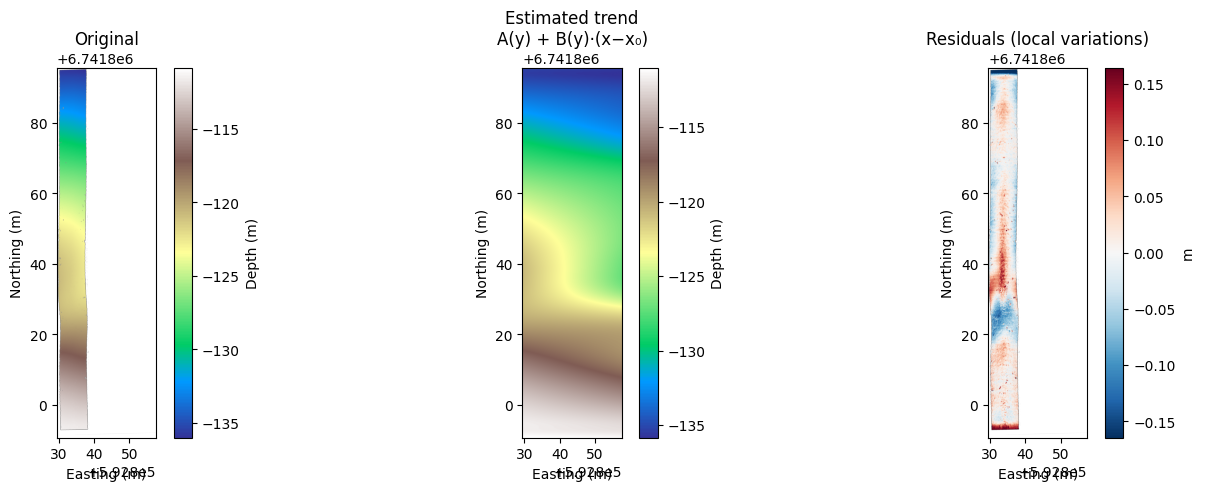

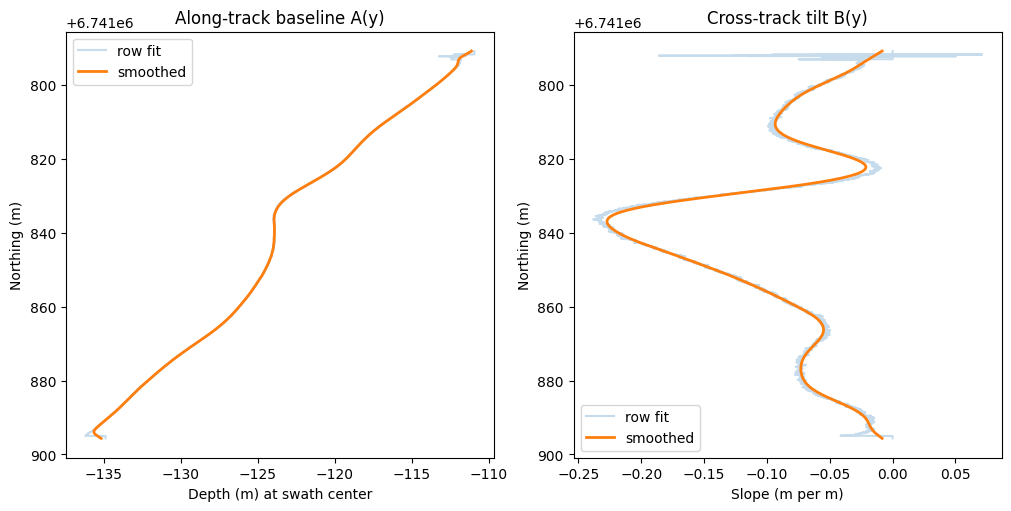

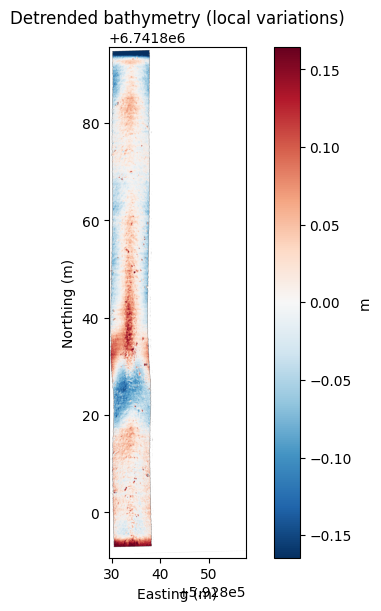

In [ ]:
# 1) Load
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# 2) Detrend with separable model (recommended)
#    - smooth_baseline_m: how aggressively to remove the roller-coaster (along-track)
#    - smooth_tilt_m: how aggressively to smooth the cross-track tilt
mb.detrend(smooth_baseline_m=1, smooth_tilt_m=2, robust=True)

# 3) Ready-made plots for your report
mb.plot_triptych()  # Original | Trend | Residuals
mb.plot_components()  # A(y) and B(y) vs northing
mb.plot_residual_heatmap()  # clean residual map only

# 4) (Optional) export residuals as GeoTIFF
# mb.save_residual_geotiff(r"E:\mjosa_new\DTM\geotiff_2_residuals.tif")

In [15]:
%matplotlib qt

In [16]:
# 1) Load
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# 2) Detrend with separable model (recommended)
#    - smooth_baseline_m: how aggressively to remove the roller-coaster (along-track)
#    - smooth_tilt_m: how aggressively to smooth the cross-track tilt
mb.detrend(smooth_baseline_m=1, smooth_tilt_m=2, robust=True)

# 3) Ready-made plots for your report
mb.plot_triptych()  # Original | Trend | Residuals
mb.plot_components()  # A(y) and B(y) vs northing
mb.plot_residual_heatmap()  # clean residual map only

# 4) (Optional) export residuals as GeoTIFF
# mb.save_residual_geotiff(r"E:\mjosa_new\DTM\geotiff_2_residuals.tif")

In [17]:
%matplotlib inline

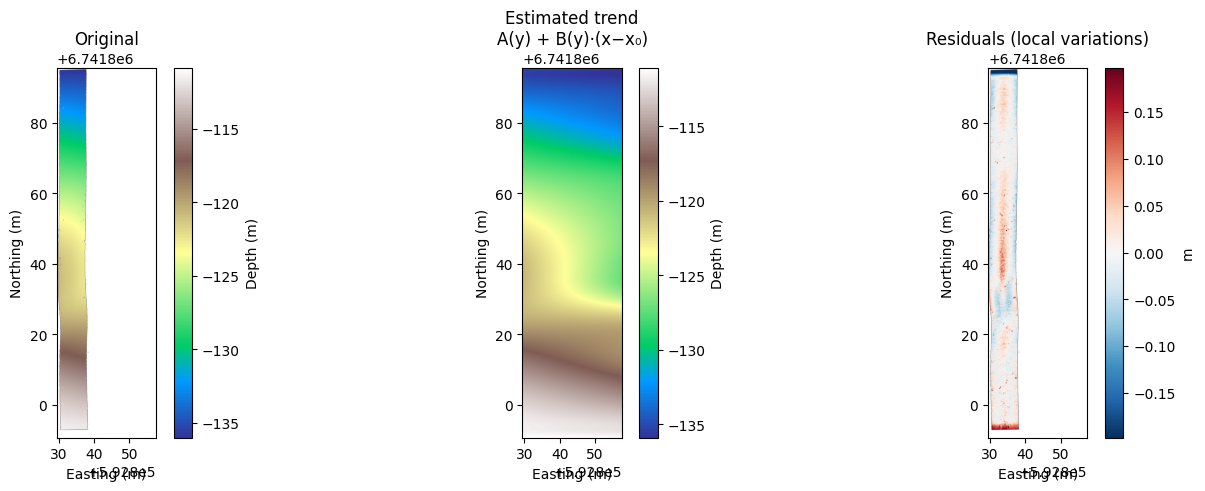

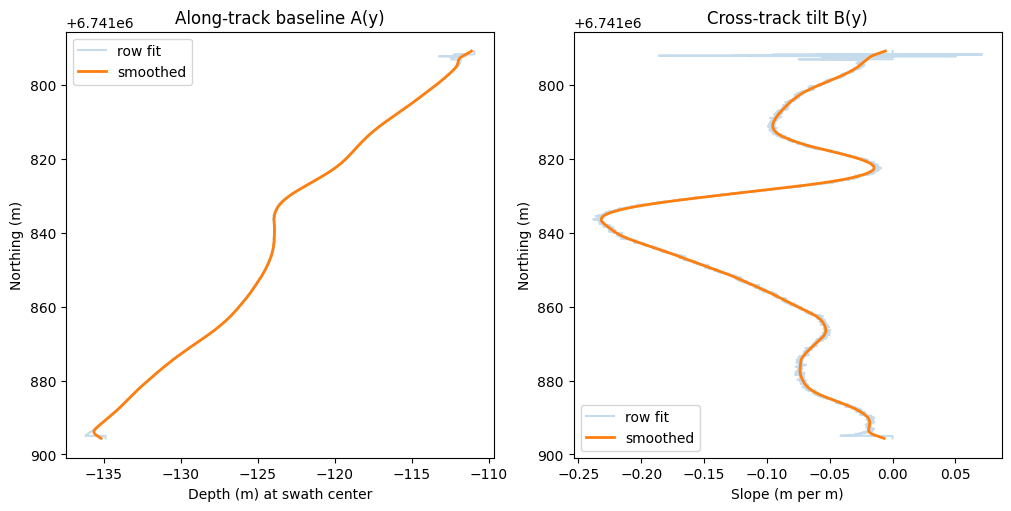

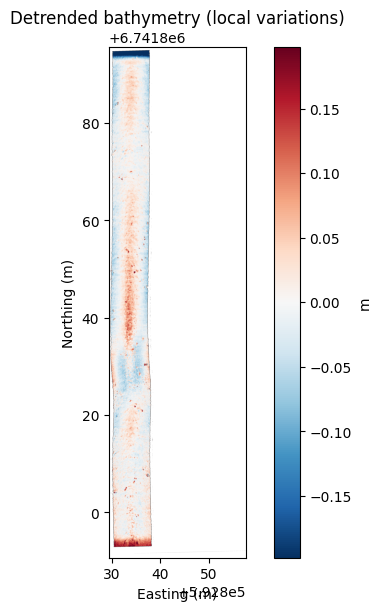

In [19]:
mb.detrend(smooth_baseline_m=1, smooth_tilt_m=1, robust=True)

# 3) Ready-made plots for your report
mb.plot_triptych()  # Original | Trend | Residuals
mb.plot_components()  # A(y) and B(y) vs northing
mb.plot_residual_heatmap()  # clean residual map only

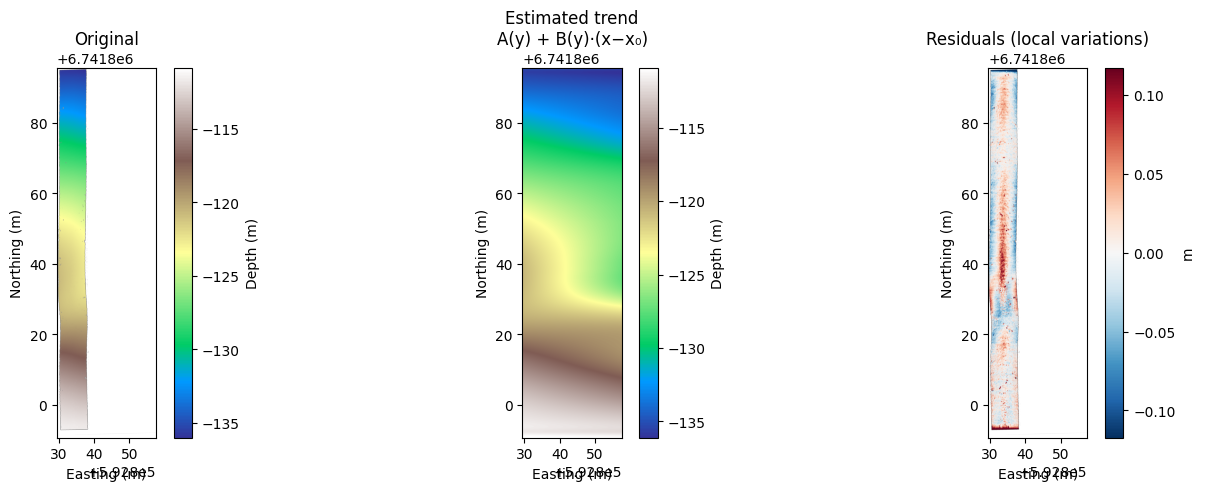

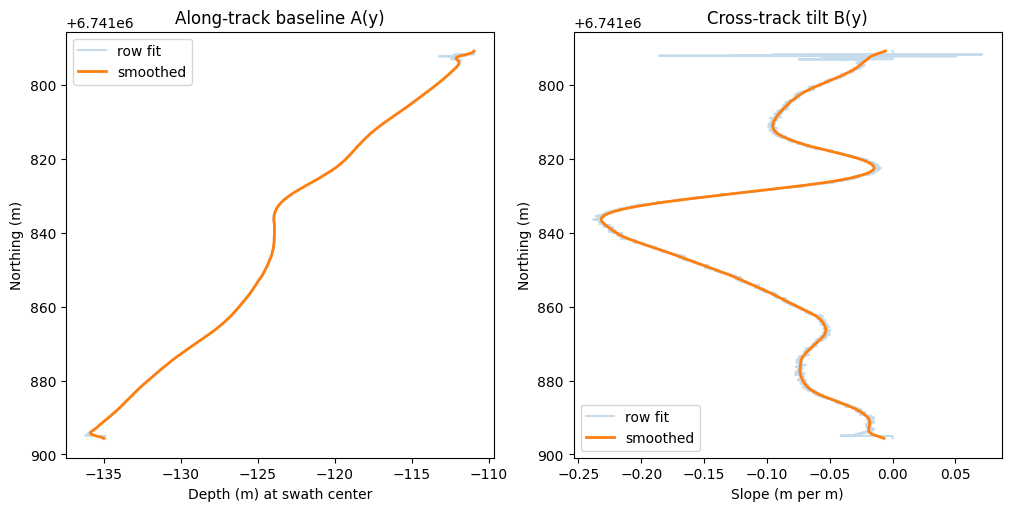

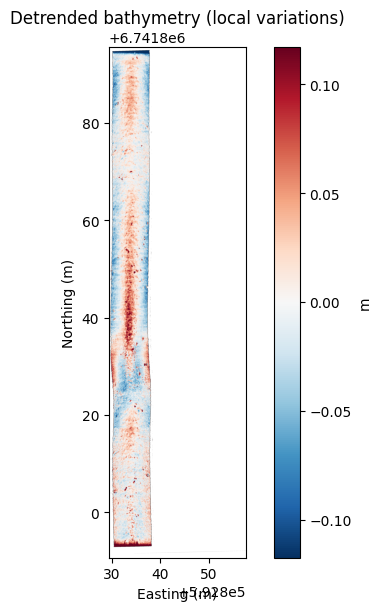

In [20]:
mb.detrend(smooth_baseline_m=0.5, smooth_tilt_m=1, robust=True)

# 3) Ready-made plots for your report
mb.plot_triptych()  # Original | Trend | Residuals
mb.plot_components()  # A(y) and B(y) vs northing
mb.plot_residual_heatmap()  # clean residual map only

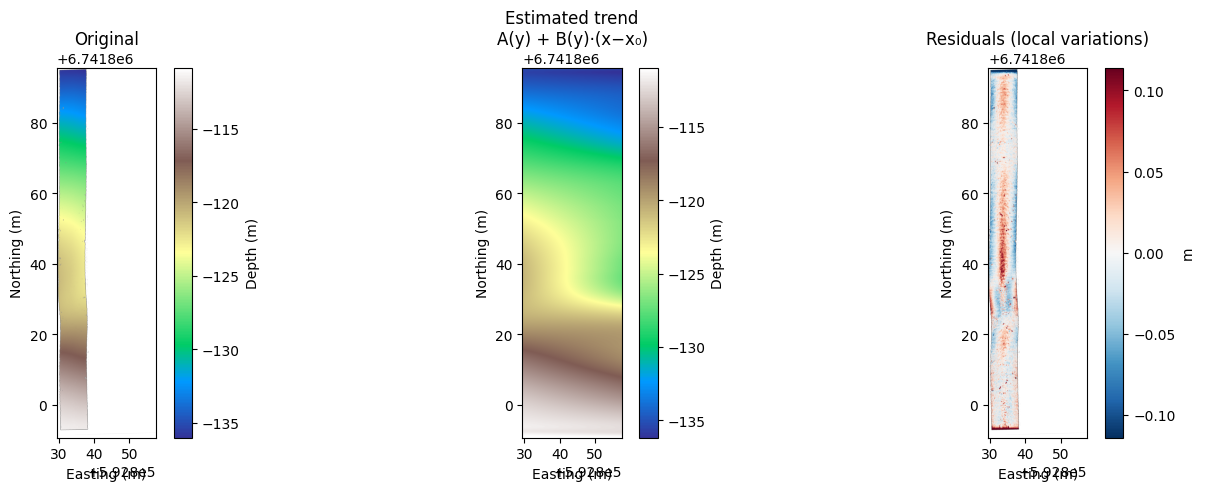

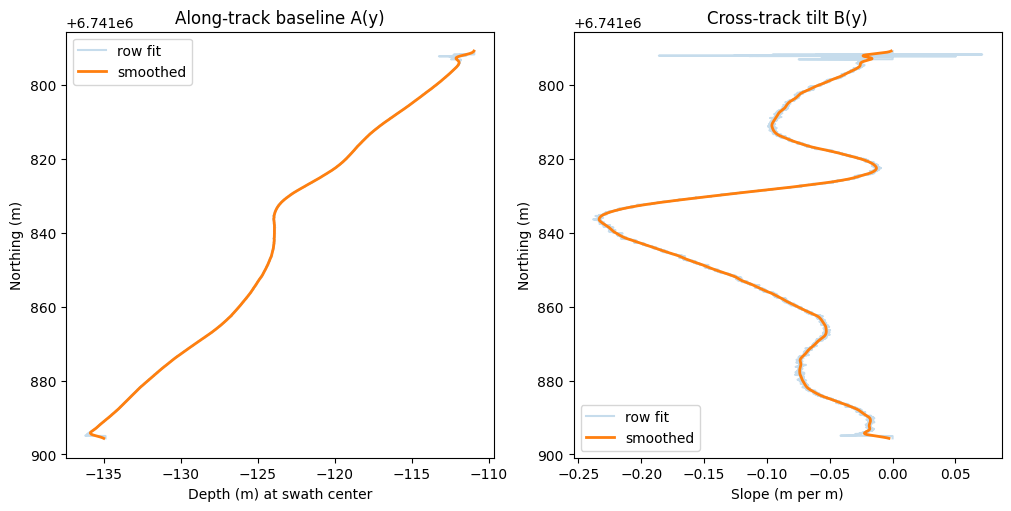

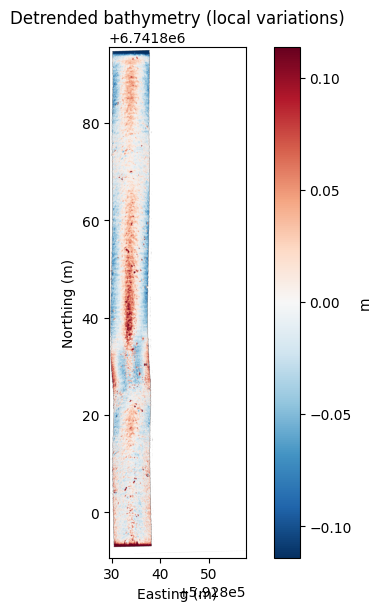

In [21]:
mb.detrend(smooth_baseline_m=0.5, smooth_tilt_m=0.5, robust=True)

# 3) Ready-made plots for your report
mb.plot_triptych()  # Original | Trend | Residuals
mb.plot_components()  # A(y) and B(y) vs northing
mb.plot_residual_heatmap()  # clean residual map only

In [24]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
from scipy.ndimage import gaussian_filter1d
from scipy.stats import median_abs_deviation


@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0

    # --- smoothing scales (meters, along-track) ---
    smooth_baseline_m: float = 10.0  # for A(y)
    smooth_tilt_m: float = 20.0  # for B(y)
    smooth_curv_m: Optional[float] = None  # for C(y); default = tilt_m
    smooth_center_m: float = 6.0  # for the swath center x̄(y)

    # --- robust fit options ---
    max_row_iters: int = 3
    clip_sigma: float = 6.0  # clip crazy A/B/C rows before smoothing
    central_frac: float = 0.8  # fit only central 80% of valid beams to avoid edges

    # internals
    data: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None

    # fitted pieces
    x_center_row: Optional[np.ndarray] = None
    x_center_s: Optional[np.ndarray] = None
    A: Optional[np.ndarray] = None
    B: Optional[np.ndarray] = None
    C: Optional[np.ndarray] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None

    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    # ---------- I/O ----------
    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            bounds = src.bounds

        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.data = z
        self.transform = tf
        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )

        # 1D coords (pixel centers) – assumes north-up (no rotation)
        a, b, c, d, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        return self

    # ---------- detrend ----------
    def detrend(
        self,
        order_x: int = 1,  # 1: linear tilt, 2: add quadratic
        remove_cross_track_tilt: bool = True,
        robust: bool = True,
        smooth_baseline_m: Optional[float] = None,
        smooth_tilt_m: Optional[float] = None,
        smooth_curv_m: Optional[float] = None,
        smooth_center_m: Optional[float] = None,
        central_frac: Optional[float] = None,
    ):
        """
        Build trend: A_s(y) + B_s(y)*(x - x̄_s(y)) [+ C_s(y)*(x - x̄_s(y))^2]
        where x̄_s(y) is the smoothed per-row swath center.
        """
        if self.data is None:
            self.load()

        # overrides
        if smooth_baseline_m is not None:
            self.smooth_baseline_m = float(smooth_baseline_m)
        if smooth_tilt_m is not None:
            self.smooth_tilt_m = float(smooth_tilt_m)
        if smooth_curv_m is not None:
            self.smooth_curv_m = float(smooth_curv_m)
        if smooth_center_m is not None:
            self.smooth_center_m = float(smooth_center_m)
        if central_frac is not None:
            self.central_frac = float(central_frac)
        if self.smooth_curv_m is None:
            self.smooth_curv_m = self.smooth_tilt_m

        z = self.data
        x = self.x_cols
        H, W = z.shape

        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        x_center = np.full(H, np.nan)

        # --- per-row robust polynomial fit around the *row's* center ---
        for i in range(H):
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue

            xv = x[m]
            yv = row[m]

            # row center = median of valid x -> avoids extrapolation when swath shifts
            xc_row = np.median(xv)
            x_center[i] = xc_row

            # use only central fraction to avoid noisy edges
            if 0 < self.central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * self.central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * self.central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row

            # initial LS fit
            deg = (
                2
                if (order_x >= 2 and remove_cross_track_tilt)
                else (1 if remove_cross_track_tilt else 0)
            )
            coef = np.polyfit(xi, yv, deg)  # highest power first
            # convert to a0 + a1*xi + a2*xi^2 with a0 = value at xi=0
            if deg == 0:
                a0 = float(coef[0])
                a1 = 0.0
                a2 = 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(self.max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)
                    # weighted LS in polynomial basis
                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    W = w
                    # normal equations with weights
                    XtW = X * W
                    beta = np.linalg.lstsq(XtW.T, (yv * W), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])
                        a2 = 0.0

            A[i] = a0
            B[i] = a1 if remove_cross_track_tilt else 0.0
            C[i] = a2 if (order_x >= 2 and remove_cross_track_tilt) else 0.0

        # --- clip crazy rows then smooth along-track (in rows) ---
        def _clip_and_fill(arr):
            s = arr.copy()
            m = np.isfinite(s)
            if m.sum() < 5:
                return s
            med = np.nanmedian(s[m])
            mad = median_abs_deviation(s[m], scale="normal") or np.nanstd(s[m])
            if not np.isfinite(mad) or mad == 0:
                return s
            lo, hi = med - self.clip_sigma * mad, med + self.clip_sigma * mad
            s[(s < lo) | (s > hi)] = np.nan
            good = np.where(np.isfinite(s))[0]
            if good.size >= 2:
                s = np.interp(np.arange(len(s)), good, s[good])
            return s

        A = _clip_and_fill(A)
        B = _clip_and_fill(B)
        C = _clip_and_fill(C)
        x_center = _clip_and_fill(x_center)

        # pixel -> meters to get Gaussian sigma in rows
        sigmaA = max(0.5, self.smooth_baseline_m / (self.px_y or 1.0))
        sigmaB = max(0.5, self.smooth_tilt_m / (self.px_y or 1.0))
        sigmaC = max(
            0.5, (self.smooth_curv_m or self.smooth_tilt_m) / (self.px_y or 1.0)
        )
        sigmaX = max(0.5, self.smooth_center_m / (self.px_y or 1.0))

        A_s = gaussian_filter1d(A, sigma=sigmaA, mode="nearest", truncate=3.5)
        B_s = gaussian_filter1d(B, sigma=sigmaB, mode="nearest", truncate=3.5)
        C_s = gaussian_filter1d(C, sigma=sigmaC, mode="nearest", truncate=3.5)
        x_center_s = gaussian_filter1d(
            x_center, sigma=sigmaX, mode="nearest", truncate=3.5
        )

        # --- reconstruct trend on the full grid (broadcasting, no huge arrays) ---
        xi_grid = self.x_cols[None, :] - x_center_s[:, None]
        trend = A_s[:, None] + B_s[:, None] * xi_grid + C_s[:, None] * (xi_grid**2)

        resid = self.data - trend
        resid[~np.isfinite(self.data)] = np.nan

        # store
        self.A, self.B, self.C = A, B, C
        self.A_s, self.B_s, self.C_s = A_s, B_s, C_s
        self.x_center_row, self.x_center_s = x_center, x_center_s
        self.trend, self.residuals = trend, resid
        return self

    # ---------- plotting ----------
    def _extent_imshow(self):
        return (self.extent[0], self.extent[1], self.extent[2], self.extent[3])

    def _robust_sym_vlim(self, arr, q=0.98):
        m = np.isfinite(arr)
        if not m.any():
            return (-1, 1)
        lo, hi = np.nanquantile(arr[m], [(1 - q) / 2, 1 - (1 - q) / 2])
        vmax = max(abs(lo), abs(hi))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = (np.nanstd(arr[m]) or 1.0) * 3
        return (-vmax, vmax)

    def plot_triptych(self, cmap_orig="terrain", cmap_resid="RdBu_r", figsize=(14, 5)):
        assert self.trend is not None, "Run detrend() first."
        fig, axs = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

        im0 = axs[0].imshow(
            self.data, extent=self._extent_imshow(), origin="upper", cmap=cmap_orig
        )
        axs[0].set_title("Original")
        axs[0].set_xlabel("Easting (m)")
        axs[0].set_ylabel("Northing (m)")
        fig.colorbar(im0, ax=axs[0], label="Depth (m)")

        im1 = axs[1].imshow(
            self.trend, extent=self._extent_imshow(), origin="upper", cmap=cmap_orig
        )
        axs[1].set_title("Estimated trend")
        axs[1].set_xlabel("Easting (m)")
        axs[1].set_ylabel("Northing (m)")
        fig.colorbar(im1, ax=axs[1], label="Depth (m)")

        vmin, vmax = self._robust_sym_vlim(self.residuals, q=0.98)
        im2 = axs[2].imshow(
            self.residuals,
            extent=self._extent_imshow(),
            origin="upper",
            cmap=cmap_resid,
            vmin=vmin,
            vmax=vmax,
        )
        axs[2].set_title("Residuals (local variations)")
        axs[2].set_xlabel("Easting (m)")
        axs[2].set_ylabel("Northing (m)")
        fig.colorbar(im2, ax=axs[2], label="m")
        plt.show()

    def plot_components(self, figsize=(12, 6)):
        assert self.A_s is not None, "Run detrend() first."
        y = self.y_rows
        fig, ax = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)

        ax[0, 0].plot(self.A, y, alpha=0.25, label="row fit")
        ax[0, 0].plot(self.A_s, y, lw=2, label="smoothed")
        ax[0, 0].invert_yaxis()
        ax[0, 0].set_title("Along-track baseline A(y)")
        ax[0, 0].set_xlabel("Depth (m) at row center")
        ax[0, 0].set_ylabel("Northing (m)")
        ax[0, 0].legend()

        ax[0, 1].plot(self.B, y, alpha=0.25, label="row fit")
        ax[0, 1].plot(self.B_s, y, lw=2, label="smoothed")
        ax[0, 1].invert_yaxis()
        ax[0, 1].set_title("Cross-track tilt B(y)")
        ax[0, 1].set_xlabel("Slope (m/m)")
        ax[0, 1].set_ylabel("Northing (m)")
        ax[0, 1].legend()

        if np.nanmax(np.abs(self.C_s)) > 0:
            ax[1, 0].plot(self.C, y, alpha=0.25, label="row fit")
            ax[1, 0].plot(self.C_s, y, lw=2, label="smoothed")
            ax[1, 0].invert_yaxis()
            ax[1, 0].set_title("Cross-track curvature C(y)")
            ax[1, 0].set_xlabel("Quadratic coeff (m/m²)")
            ax[1, 0].set_ylabel("Northing (m)")
            ax[1, 0].legend()

        ax[1, 1].plot(self.x_center_row, y, alpha=0.25, label="row median x")
        ax[1, 1].plot(self.x_center_s, y, lw=2, label="smoothed")
        ax[1, 1].invert_yaxis()
        ax[1, 1].set_title("Swath center x̄(y)")
        ax[1, 1].set_xlabel("Easting (m)")
        ax[1, 1].set_ylabel("Northing (m)")
        ax[1, 1].legend()
        plt.show()

    def plot_residual_heatmap(self, figsize=(6, 12), cmap="RdBu_r", vmax=None):
        assert self.residuals is not None, "Run detrend() first."
        if vmax is None:
            vmin, vmax = self._robust_sym_vlim(self.residuals, q=0.98)
        else:
            vmin = -abs(vmax)
            vmax = abs(vmax)
        fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
        im = ax.imshow(
            self.residuals,
            extent=self._extent_imshow(),
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title("Detrended bathymetry (local variations)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        fig.colorbar(im, ax=ax, label="m")
        plt.show()

    def save_residual_geotiff(self, out_path: str):
        assert (
            self.residuals is not None and self.transform is not None
        ), "Run detrend() first."
        with rasterio.open(self.tif_path) as src:
            profile = src.profile
        profile.update(dtype="float32", count=1, nodata=np.nan)
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(self.residuals.astype("float32"), 1)
        print(f"✅ Saved: {out_path}")

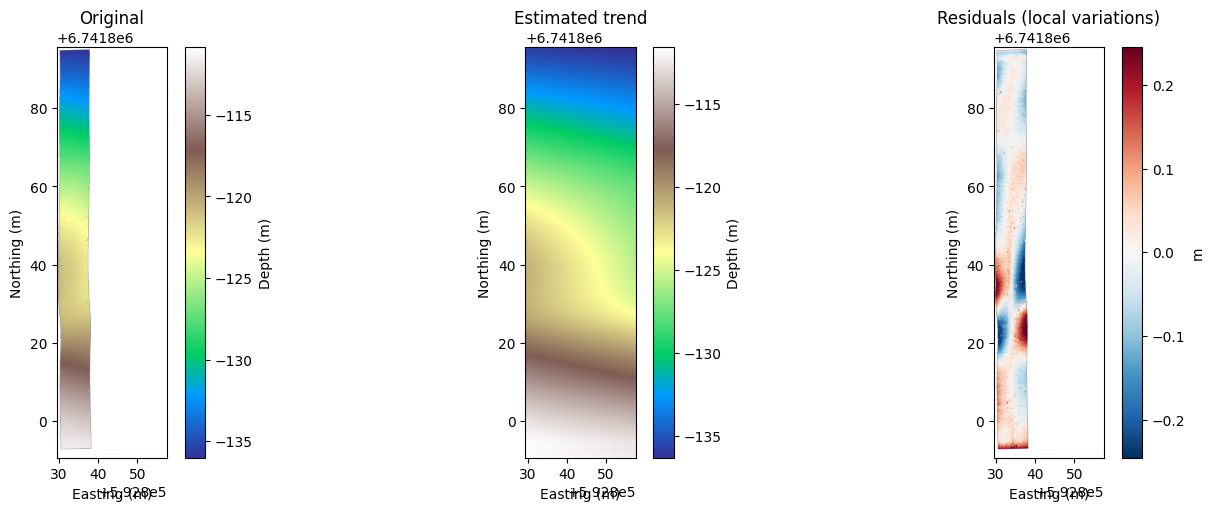

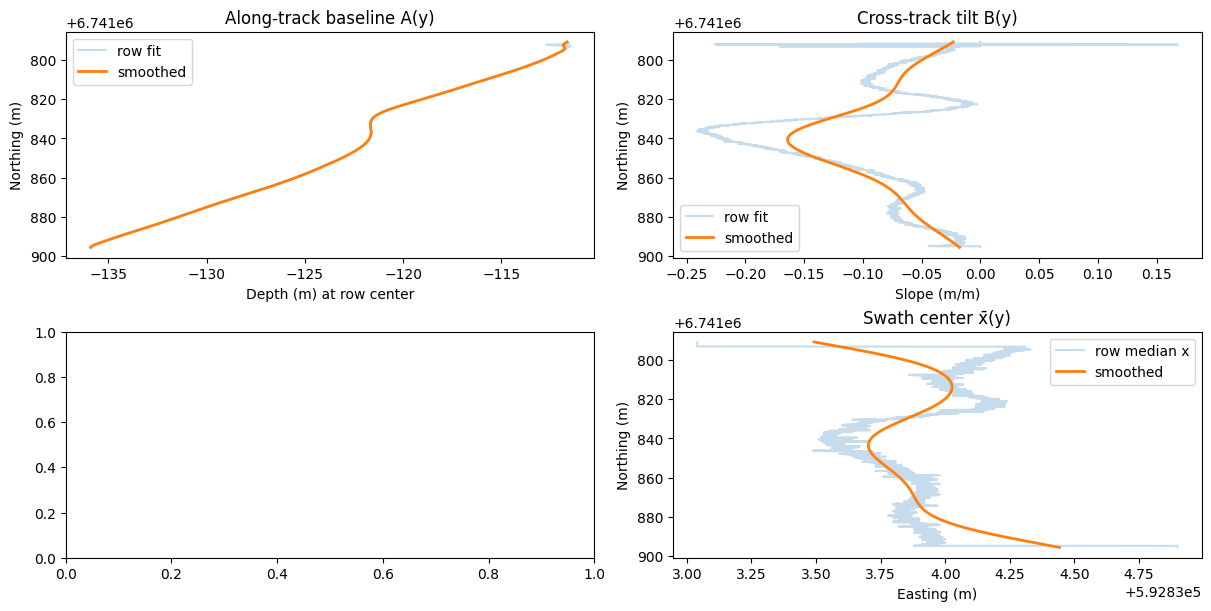

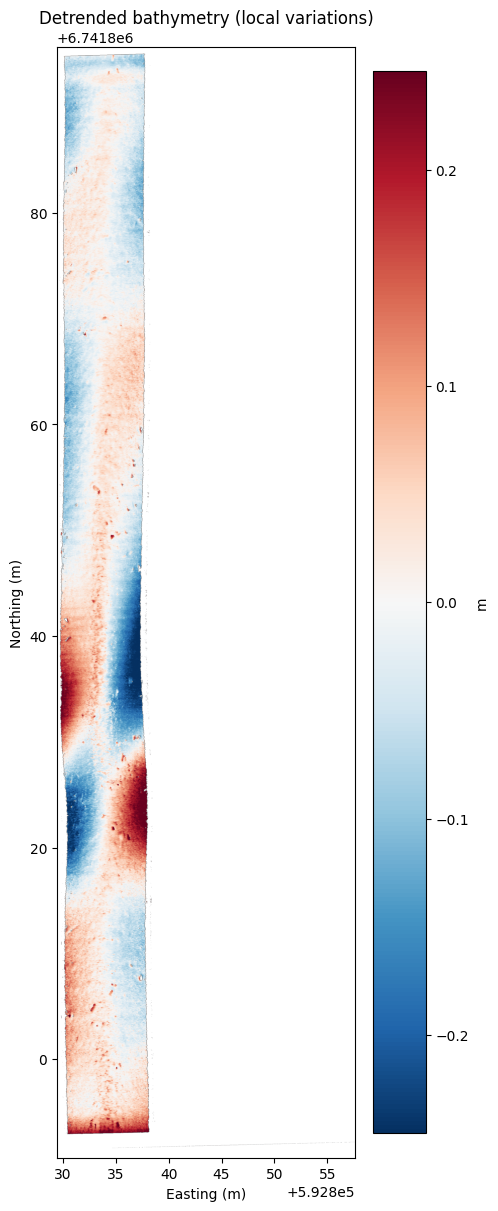

In [42]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# Start here:
mb.detrend(
    order_x=0,  # allow gentle cross-track curvature
    smooth_baseline_m=1,  # along-track smoothing of A(y)
    smooth_tilt_m=10,  # along-track smoothing of B(y)
    smooth_center_m=10,  # smooth the drifting swath center
    central_frac=0.8,  # fit central 80% of beams
    robust=True,
)

mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap(figsize=(5, 12))

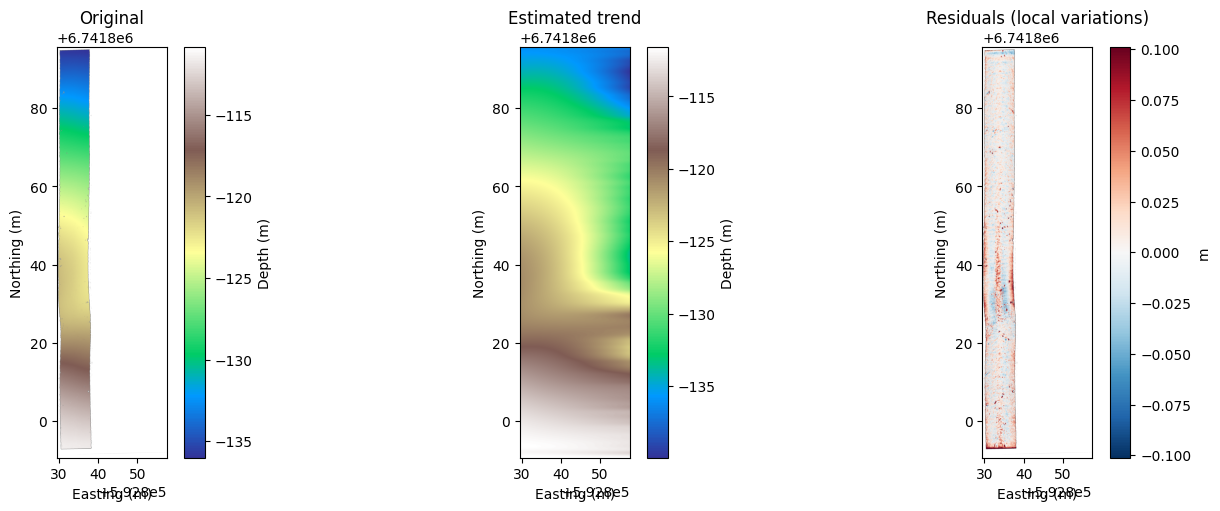

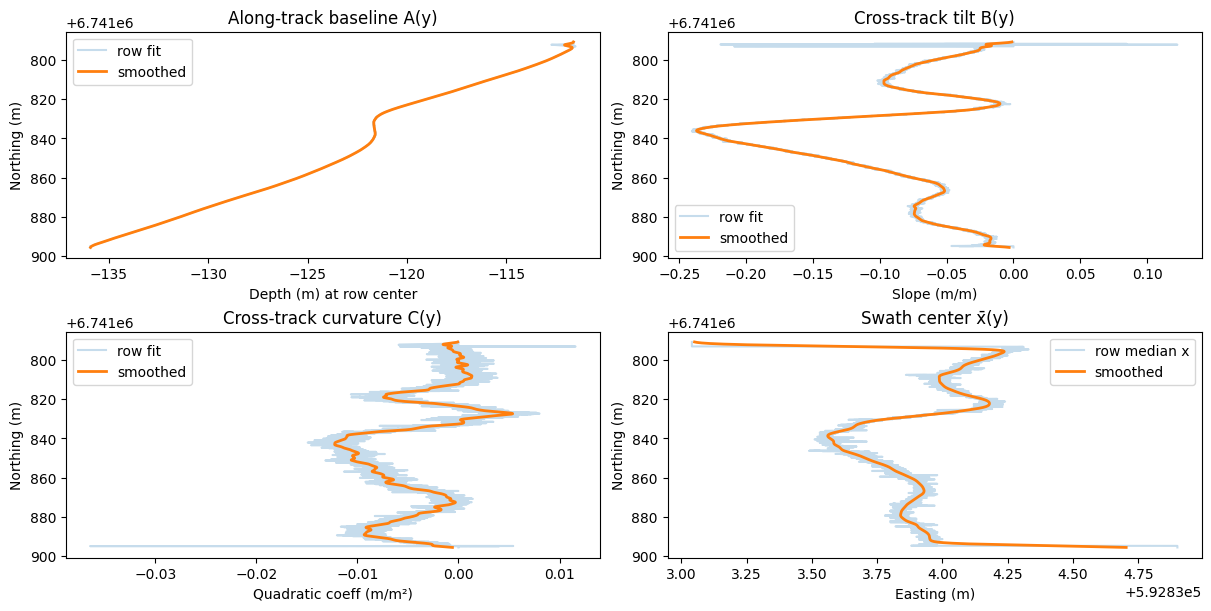

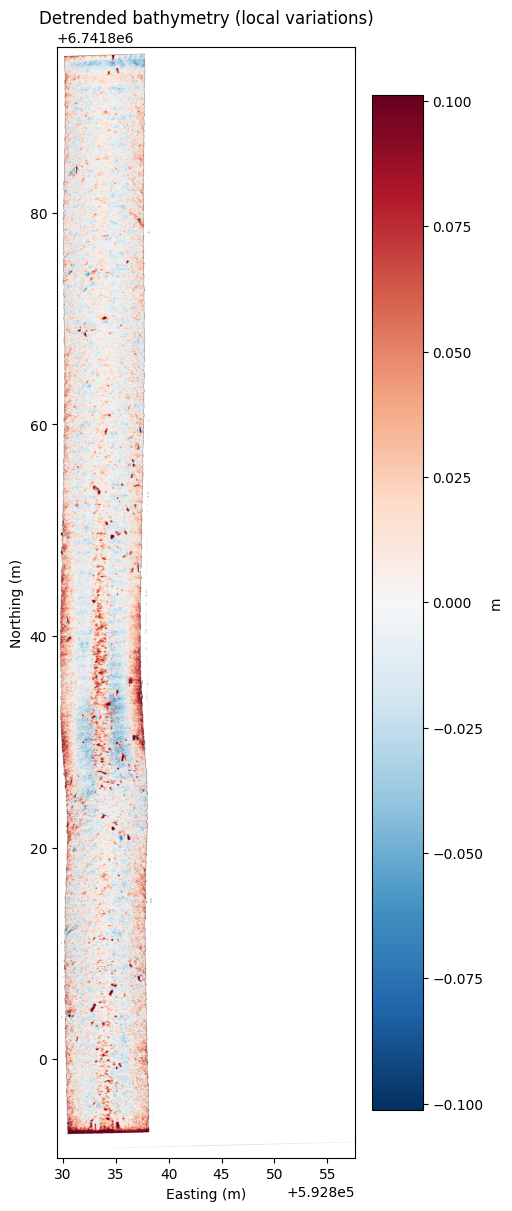

In [24]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# Start here:
mb.detrend(
    order_x=2,  # allow gentle cross-track curvature
    smooth_baseline_m=0.5,  # along-track smoothing of A(y)
    smooth_tilt_m=0.5,  # along-track smoothing of B(y)
    smooth_center_m=1,  # smooth the drifting swath center
    central_frac=0.8,  # fit central 80% of beams
    robust=True,
)

mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap(figsize=(5, 12))

In [15]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# Start here:
mb.detrend(
    order_x=2,  # allow gentle cross-track curvature
    smooth_baseline_m=0.1,  # along-track smoothing of A(y)
    smooth_tilt_m=0.1,  # along-track smoothing of B(y)
    smooth_center_m=1,  # smooth the drifting swath center
    central_frac=0.8,  # fit central 80% of beams
    robust=True,
)

mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap(figsize=(5, 12))

In [21]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


def _meters_to_sigma_px(value_m, pixel_size_m):
    """
    Convert a smoothing length in meters to Gaussian sigma in pixels.
    0 or None => 0 px (OFF).
    """
    if value_m is None:
        return 0.0
    try:
        v = float(value_m)
    except Exception:
        return 0.0
    if v <= 0:
        return 0.0
    return v / abs(float(pixel_size_m))


def _smooth1d(arr, sigma_px):
    """
    Gaussian smooth a 1D array. If sigma_px <= 0, return a copy unchanged.
    """
    a = np.asarray(arr, float)
    if sigma_px <= 0:
        return a.copy()
    return gaussian_filter1d(a, sigma=sigma_px, mode="nearest")


def _central_slice(ncols, central_frac):
    """
    Choose central columns. If frac is None or out of (0,1], default to 1.0.
    """
    if central_frac is None:
        frac = 1.0
    else:
        frac = float(central_frac)
        if not (0.0 < frac <= 1.0):
            frac = 1.0
    w = max(1, int(round(ncols * frac)))
    left = (ncols - w) // 2
    right = left + w
    return slice(left, right)


# ---- Patch the class methods to use the helpers above ----


def _patched_detrend(
    self,
    order_x=1,
    smooth_baseline_m=None,
    smooth_tilt_m=None,
    smooth_center_m=None,
    central_frac=0.8,
    robust=True,
    debug=False,
):
    """
    Same API as before; now 0/None = OFF for all *_m knobs and central_frac is validated.
    """
    if self.data is None:
        self.load()

    Z = self.data.copy()
    valid = np.isfinite(Z)
    nrows, ncols = Z.shape

    # pixel sizes from transform (dy is along-track)
    dx = abs(float(self.transform.a))
    dy = abs(float(self.transform.e))

    # effective sigmas in pixels
    sigA = _meters_to_sigma_px(smooth_baseline_m, dy)
    sigB = _meters_to_sigma_px(smooth_tilt_m, dy)
    sigC = _meters_to_sigma_px(smooth_center_m, dy)

    if debug:
        print(f"dx={dx:.3f} m/col, dy={dy:.3f} m/row")
        print(
            f"sigma_baseline_px={sigA:.3f}, sigma_tilt_px={sigB:.3f}, sigma_center_px={sigC:.3f}"
        )
        print(f"central_frac={central_frac}")

    use_cols = _central_slice(ncols, central_frac)

    # build across-track coordinate (centered)
    x = (np.arange(ncols) - (ncols - 1) / 2.0) * dx
    X = x[use_cols]

    # per-row least-squares to get A(y)+B(y)x+... up to order_x
    deg = int(order_x)
    Z_fit = np.full_like(Z, np.nan, float)

    # coefficients vs row
    coeffs = np.full((deg + 1, nrows), np.nan, float)  # [A, B, C, ...]

    for r in range(nrows):
        mask = valid[r, use_cols]
        if not np.any(mask):
            continue
        yrow = Z[r, use_cols][mask]
        Xrow = X[mask]

        # design matrix
        cols = [np.ones_like(Xrow)]
        if deg >= 1:
            cols.append(Xrow)
        if deg >= 2:
            cols.append(Xrow**2)
        if deg >= 3:
            cols.append(Xrow**3)
        A = np.vstack(cols).T  # (npts, p)

        if robust:
            # simple robust weighting loop
            w = np.ones_like(yrow)
            for _ in range(3):
                Aw = A * w[:, None]
                bw = yrow * w
                beta, *_ = np.linalg.lstsq(Aw, bw, rcond=None)
                resid = yrow - A @ beta
                mad = np.median(np.abs(resid)) + 1e-9
                w = 1.0 / np.clip(np.abs(resid) / (1.4826 * mad), 1.0, np.inf)
        else:
            beta, *_ = np.linalg.lstsq(A, yrow, rcond=None)

        coeffs[: len(beta), r] = beta

    # smooth sequences along-track (A(y), B(y), C(y)...) if requested
    coeffs[0, :] = _smooth1d(coeffs[0, :], sigA)  # baseline A(y)
    for k in range(1, deg + 1):
        coeffs[k, :] = _smooth1d(coeffs[k, :], sigB)  # same sigma for B, C, ...

    # (optional) smooth swath center x̄(y)
    row_median_x = np.full(nrows, np.nan)
    for r in range(nrows):
        row_median_x[r] = np.nanmedian(np.where(valid[r], x, np.nan))
    center_track = _smooth1d(row_median_x, sigC)

    # reconstruct trend and residuals
    for r in range(nrows):
        # shift x so that the polynomial is evaluated around the (smoothed) center
        x_rel = x - center_track[r]
        terms = [np.ones_like(x_rel)]
        if deg >= 1:
            terms.append(x_rel)
        if deg >= 2:
            terms.append(x_rel**2)
        if deg >= 3:
            terms.append(x_rel**3)
        beta = coeffs[: len(terms), r]
        Z_fit[r, :] = np.sum(np.vstack(terms).T * beta[None, :], axis=1)

    self.trend = Z_fit
    self.residuals = np.where(valid, Z - Z_fit, np.nan)
    self._components = {
        "A": coeffs[0, :],
        "B": coeffs[1, :] if deg >= 1 else None,
        "C": coeffs[2, :] if deg >= 2 else None,
        "center_x": center_track,
        "row_median_x": row_median_x,
        "sig_px": {"A": sigA, "tilt": sigB, "center": sigC},
        "dx": dx,
        "dy": dy,
    }
    return self


# install the patch
MBESDetrender.detrend = _patched_detrend

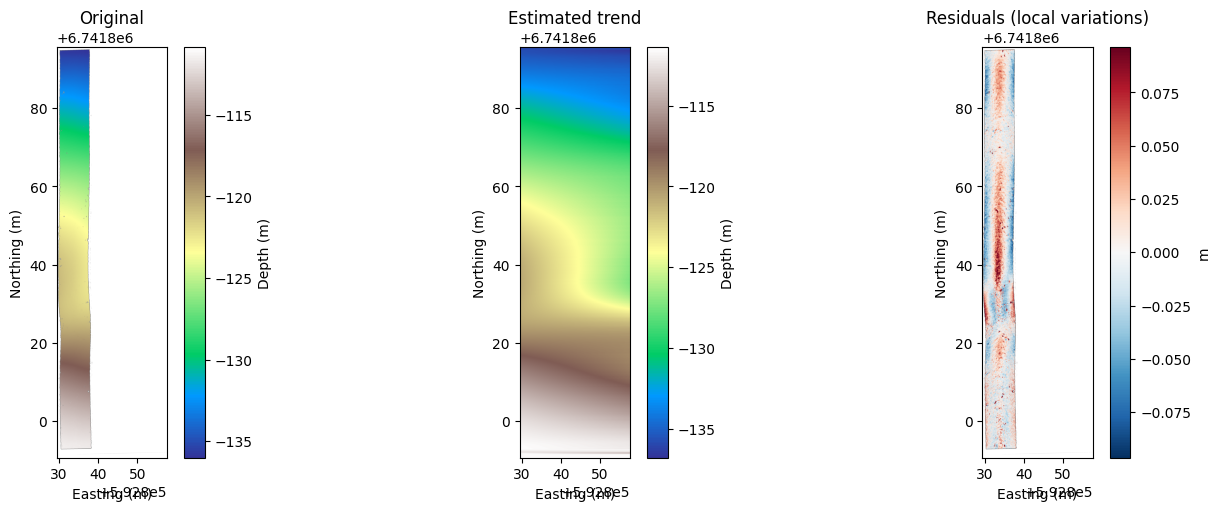

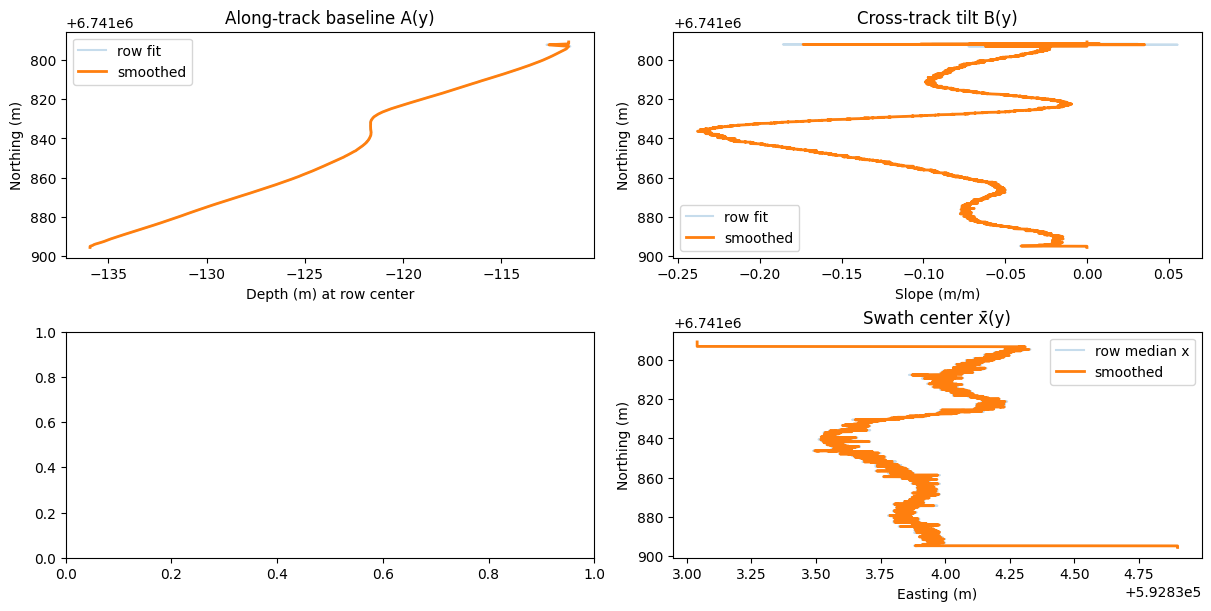

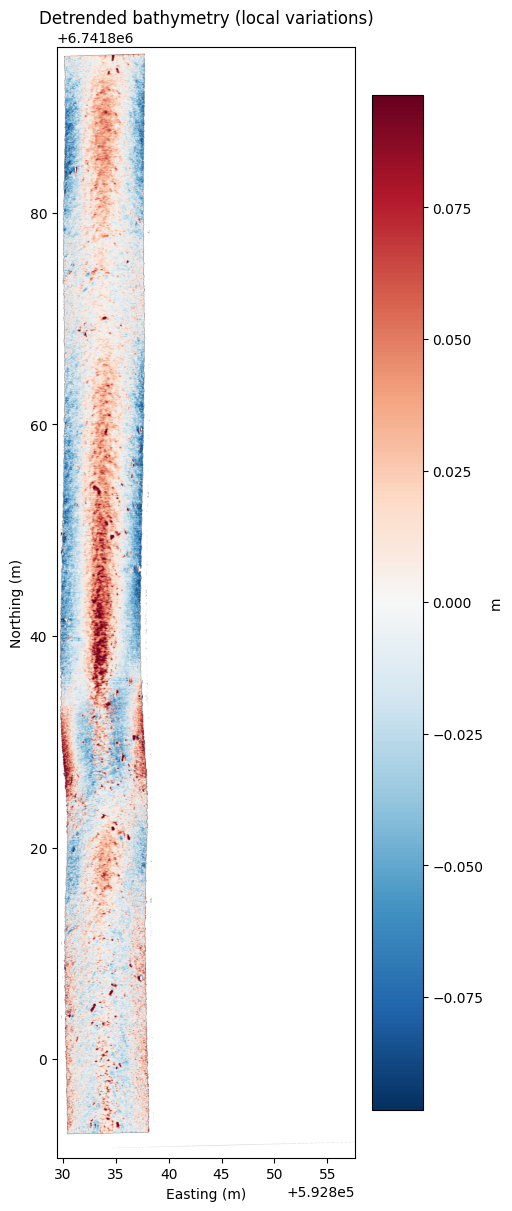

In [25]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# Start here:
mb.detrend(
    order_x=0,  # allow gentle cross-track curvature
    smooth_baseline_m=0.1,  # along-track smoothing of A(y)
    smooth_tilt_m=0,  # along-track smoothing of B(y)
    smooth_center_m=0,  # smooth the drifting swath center
    central_frac=1,  # fit central 80% of beams
    robust=True,
)

mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap(figsize=(5, 12))

In [19]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


def _meters_to_cols(mb, m):
    dx = float(mb.transform.a)  # pixel size in x (m/col)
    return max(1.0, m / dx)


def _meters_to_rows(mb, m):
    dy = abs(float(mb.transform.e))  # pixel size in y (m/row)
    return max(1.0, m / dy)


def destripe_by_column_median(mb, smooth_cols_m=0.4):
    """
    Remove persistent per-column bias (beam-angle stripe).
    - smooth_cols_m: how much to smooth the column template along X (meters).
    """
    Z = mb.residuals
    if Z is None:
        raise RuntimeError("Run mb.detrend(...) first.")

    # robust column template
    col_med = np.nanmedian(Z, axis=0)

    # smooth across columns by ~smooth_cols_m (convert meters -> sigma in cols)
    sigma_cols = _meters_to_cols(mb, smooth_cols_m) / 2.355  # FWHM->sigma
    col_med_s = gaussian_filter1d(col_med, sigma=sigma_cols, mode="nearest")

    mb.residuals = Z - col_med_s[None, :]
    mb._col_template = col_med_s  # for plots if you want


def row_demean_central(mb, central_frac=0.8, smooth_alongtrack_m=1.5):
    """
    Re-zero each row using only the central band (no extrapolation to edges).
    - central_frac: width of the central band used for the row median (0–1).
      e.g. 0.8 = use middle 80% of beams for the robust row reference.
    - smooth_alongtrack_m: optional smoothing of that 1D row baseline (meters).
    """
    Z = mb.residuals
    if Z is None:
        raise RuntimeError("Run mb.detrend(...) first.")

    nrows, ncols = Z.shape
    m = int((1.0 - central_frac) * 0.5 * ncols)
    c0, c1 = max(0, m), max(m, ncols - m)  # central slice [c0:c1]

    # robust row baseline from the central band
    row_med = np.nanmedian(Z[:, c0:c1], axis=1)

    # smooth baseline along track (optional but stabilizes)
    if smooth_alongtrack_m and smooth_alongtrack_m > 0:
        sigma_rows = _meters_to_rows(mb, smooth_alongtrack_m) / 2.355
        row_med = gaussian_filter1d(row_med, sigma=sigma_rows, mode="nearest")

    mb.residuals = Z - row_med[:, None]
    mb._row_template = row_med  # for plots if you want


def postprocess_fix_stripes_and_ramp(
    mb,
    central_frac=0.8,
    stripe_smooth_cols_m=0.4,
    row_baseline_smooth_m=1.5,
):
    """
    Convenience wrapper: 1) destripe columns, 2) re-zero rows by central band.
    Use this right after your mb.detrend(...) that already looks “best”.
    """
    destripe_by_column_median(mb, smooth_cols_m=stripe_smooth_cols_m)
    row_demean_central(
        mb, central_frac=central_frac, smooth_alongtrack_m=row_baseline_smooth_m
    )

In [38]:
%matplotlib qt

c:\conda_envs\my_env\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


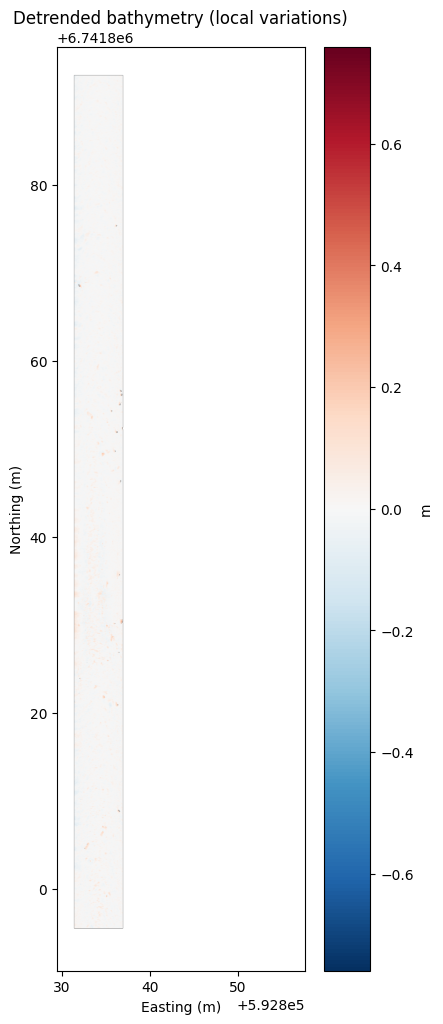

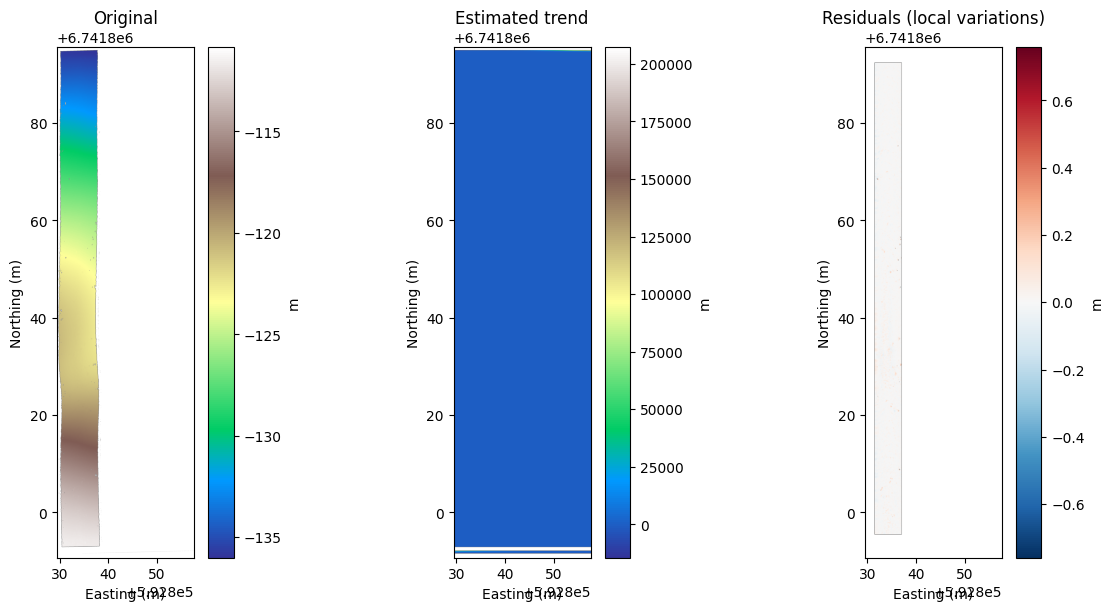

In [20]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# your favorite settings
mb.detrend(
    order_x=3,
    smooth_baseline_m=0.1,
    smooth_tilt_m=0.1,
    smooth_center_m=0.1,
    central_frac=0.8,
    robust=True,
)

# tiny, safe clean-ups to remove center/edge band + slow along-track ramp
postprocess_fix_stripes_and_ramp(
    mb,
    central_frac=0.8,  # same as your fit
    stripe_smooth_cols_m=1,  # smooth width of the column stripe template
    row_baseline_smooth_m=1.5,  # smooth the per-row baseline just a little
)

# plots
mb.plot_residual_heatmap(figsize=(5, 12))
# (Optional) also see original/trend/residuals:
mb.plot_triptych()

In [16]:
# === MBES detrending (copy-paste whole block) ===============================
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


def _meters_to_sigma_px(value_m, pixel_size_m):
    """
    Convert a smoothing length in meters (along-track) to Gaussian sigma in pixels.
    0 or None => 0 px (OFF).
    """
    if value_m is None:
        return 0.0
    try:
        v = float(value_m)
    except Exception:
        return 0.0
    if v <= 0:
        return 0.0
    return v / abs(float(pixel_size_m))


def _gfilter1d_ignore_nan(arr, sigma_px):
    """
    Gaussian filter that ignores NaNs via weight normalization.
    If sigma_px <= 0, return a copy unchanged.
    """
    a = np.asarray(arr, dtype=float)
    if sigma_px <= 0:
        return a.copy()

    mask = np.isfinite(a).astype(float)
    a_filled = np.where(np.isfinite(a), a, 0.0)

    num = gaussian_filter1d(a_filled, sigma=sigma_px, mode="nearest")
    den = gaussian_filter1d(mask, sigma=sigma_px, mode="nearest")
    out = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 1e-12)
    return out


def _central_slice(ncols, frac):
    """
    Central slice of columns. If frac is None or invalid, default to 1.0.
    """
    if frac is None:
        frac = 1.0
    else:
        frac = float(frac)
        if not (0.0 < frac <= 1.0):
            frac = 1.0
    w = max(1, int(round(ncols * frac)))
    left = (ncols - w) // 2
    right = left + w
    return slice(left, right)


class MBESDetrender:
    """
    Minimal, robust MBES detrending.

    Detrend model per row r (cross-track x), with x measured in meters and
    centered on a per-row swath center x̄(r):

        z_trend(r, x) = A(r) + B(r)*(x - x̄(r)) + C(r)*(x - x̄(r))^2 + ...

    The sequences A(r), B(r), ... are optionally smoothed along-track (r).
    The center track x̄(r) can also be smoothed along-track.

    Parameters you can tune:
        order_x            : 0..3 (0 = baseline only, 1 = +tilt, 2/3 = +curvature/cubic)
        smooth_baseline_m  : Gaussian sigma (meters along-track) for A(r). 0/None = OFF
        smooth_tilt_m      : Gaussian sigma (meters) for B(r), C(r), ... 0/None = OFF
        smooth_center_m    : Gaussian sigma (meters) for x̄(r). 0/None = OFF
        central_frac       : (0, 1] fraction of swath width used for fitting (e.g. 0.8)
        robust             : simple iteratively reweighted least squares (3 iters)

    Usage:
        mb = MBESDetrender("path/to.tif").load()
        mb.detrend(order_x=1, smooth_baseline_m=0.2, smooth_tilt_m=0.2,
                   smooth_center_m=0.5, central_frac=0.8, robust=True, debug=True)
        mb.plot_triptych()
        mb.plot_components()
        mb.plot_residual_heatmap()
    """

    def __init__(self, tif_path):
        self.path = tif_path
        self.data = None
        self.transform = None
        self.bounds = None
        self.crs = None

        # convenience
        self.dx = None  # meters/column
        self.dy = None  # meters/row
        self.extent = None  # imshow extent (xmin, xmax, ymin, ymax)

        # outputs
        self.trend = None
        self.residuals = None

        # components (raw & smoothed) for plotting
        self.A_raw = None
        self.A_s = None
        self.B_raw = None
        self.B_s = None
        self.C_raw = None
        self.C_s = None
        self.D_raw = None
        self.D_s = None
        self.center_raw = None
        self.center_s = None

        # y coordinate (northing) for component plots
        self.y_rows = None

    # --------------------------- IO -----------------------------------------
    def load(self):
        with rasterio.open(self.path) as src:
            Z = src.read(1).astype(float)
            nodata = src.nodata
            self.transform = src.transform
            self.bounds = src.bounds
            self.crs = src.crs

        # nodata handling
        if nodata is not None:
            Z[Z == nodata] = np.nan
        # common sentinel too-large values (just in case)
        Z[np.abs(Z) > 1e5] = np.nan
        self.data = Z

        # pixel sizes (note: e is typically negative for north-up geotiffs)
        self.dx = abs(float(self.transform.a))
        self.dy = abs(float(self.transform.e))

        # extent for imshow
        self.extent = (
            self.bounds.left,
            self.bounds.right,
            self.bounds.bottom,
            self.bounds.top,
        )

        # y (northing) per row center for component plots
        nrows = Z.shape[0]
        # row index -> y at pixel center
        # y = f + e*row + d*col; at center col, omit d*col term by using col=0
        f = self.transform.f
        e = self.transform.e
        # use pixel-center shift of e/2
        y_centers = f + e * (np.arange(nrows) + 0.5)
        self.y_rows = y_centers

        return self

    # ------------------------- core detrend ---------------------------------
    def detrend(
        self,
        order_x=1,
        smooth_baseline_m=None,
        smooth_tilt_m=None,
        smooth_center_m=None,
        central_frac=0.8,
        robust=True,
        debug=False,
    ):
        assert self.data is not None, "Call .load() first."

        Z = self.data
        valid = np.isfinite(Z)
        nrows, ncols = Z.shape

        # smoothing sigmas in pixels (along track = rows)
        sigA = _meters_to_sigma_px(smooth_baseline_m, self.dy)
        sigT = _meters_to_sigma_px(smooth_tilt_m, self.dy)
        sigC = _meters_to_sigma_px(smooth_center_m, self.dy)

        if debug:
            print(f"dx={self.dx:.3f} m/col, dy={self.dy:.3f} m/row")
            print(
                f"sigma_baseline_px={sigA:.3f}, sigma_tilt_px={sigT:.3f}, sigma_center_px={sigC:.3f}"
            )
            print(f"central_frac={central_frac}")

        use_cols = _central_slice(ncols, central_frac)

        # cross-track x (meters) for ALL columns, centered about grid middle.
        xcols = (np.arange(ncols) - (ncols - 1) / 2.0) * self.dx

        # per-row swath center (raw median of valid x)
        center_raw = np.full(nrows, np.nan)
        for r in range(nrows):
            if not np.any(valid[r]):
                continue
            # median of x where depth is valid
            center_raw[r] = np.nanmedian(xcols[valid[r]])

        # smoothed swath center if requested
        center_s = _gfilter1d_ignore_nan(center_raw, sigC)

        deg = int(order_x)
        P = deg + 1  # number of coefficients

        coeff_raw = np.full((P, nrows), np.nan, float)  # rows of [A, B, C, D]
        trend = np.full_like(Z, np.nan, float)

        # design & robust fit per row
        for r in range(nrows):
            mask_row = valid[r, use_cols]
            if not np.any(mask_row):
                continue

            x_rel = xcols[use_cols] - center_s[r]  # x relative to (smoothed) center
            x_rel = x_rel[mask_row]
            z_row = Z[r, use_cols][mask_row]

            # build Vandermonde up to deg
            cols = [np.ones_like(x_rel)]
            if deg >= 1:
                cols.append(x_rel)
            if deg >= 2:
                cols.append(x_rel**2)
            if deg >= 3:
                cols.append(x_rel**3)
            A = np.vstack(cols).T  # (Npts, P)

            if robust:
                w = np.ones_like(z_row)
                for _ in range(3):
                    Aw = A * w[:, None]
                    bw = z_row * w
                    beta, *_ = np.linalg.lstsq(Aw, bw, rcond=None)
                    resid = z_row - A @ beta
                    mad = np.median(np.abs(resid)) + 1e-9
                    w = 1.0 / np.clip(np.abs(resid) / (1.4826 * mad), 1.0, np.inf)
            else:
                beta, *_ = np.linalg.lstsq(A, z_row, rcond=None)

            coeff_raw[: len(beta), r] = beta

        # smooth coefficients along-track
        A_raw = coeff_raw[0, :]
        A_s = _gfilter1d_ignore_nan(A_raw, sigA)

        B_raw = coeff_raw[1, :] if deg >= 1 else None
        C_raw = coeff_raw[2, :] if deg >= 2 else None
        D_raw = coeff_raw[3, :] if deg >= 3 else None

        B_s = _gfilter1d_ignore_nan(B_raw, sigT) if B_raw is not None else None
        C_s = _gfilter1d_ignore_nan(C_raw, sigT) if C_raw is not None else None
        D_s = _gfilter1d_ignore_nan(D_raw, sigT) if D_raw is not None else None

        # reconstruct trend per row for all columns
        for r in range(nrows):
            if not np.any(valid[r]):
                continue

            x_rel_full = xcols - center_s[r]
            terms = [np.ones_like(x_rel_full)]  # A
            if deg >= 1:
                terms.append(x_rel_full)  # B
            if deg >= 2:
                terms.append(x_rel_full**2)  # C
            if deg >= 3:
                terms.append(x_rel_full**3)  # D

            betas = [A_s[r]]
            if deg >= 1:
                betas.append(B_s[r])
            if deg >= 2:
                betas.append(C_s[r])
            if deg >= 3:
                betas.append(D_s[r])

            trend[r, :] = np.sum(np.vstack(terms).T * np.array(betas)[None, :], axis=1)

        residuals = np.where(valid, Z - trend, np.nan)

        # save outputs & components for plotting
        self.trend = trend
        self.residuals = residuals

        self.A_raw, self.A_s = A_raw, A_s
        self.B_raw, self.B_s = B_raw, B_s
        self.C_raw, self.C_s = C_raw, C_s
        self.D_raw, self.D_s = D_raw, D_s
        self.center_raw, self.center_s = center_raw, center_s

        return self

    # --------------------------- plots --------------------------------------
    def plot_triptych(
        self, vmin=None, vmax=None, cmap="terrain", cmap_resid="RdBu_r", figsize=(12, 6)
    ):
        assert (
            self.trend is not None and self.residuals is not None
        ), "Run detrend() first."
        fig, axs = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

        im0 = axs[0].imshow(
            self.data,
            extent=self.extent,
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        axs[0].set_title("Original")
        axs[0].set_xlabel("Easting (m)")
        axs[0].set_ylabel("Northing (m)")
        fig.colorbar(im0, ax=axs[0], label="m")

        im1 = axs[1].imshow(
            self.trend,
            extent=self.extent,
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        axs[1].set_title("Estimated trend")
        axs[1].set_xlabel("Easting (m)")
        axs[1].set_ylabel("Northing (m)")
        fig.colorbar(im1, ax=axs[1], label="m")

        # symmetric residual range if not provided
        if vmin is None or vmax is None:
            r = np.nanmax(np.abs(self.residuals))
            r = float(r) if np.isfinite(r) else None
            vmin_r, vmax_r = (-r, r) if r is not None else (None, None)
        else:
            vmin_r, vmax_r = (vmin, vmax)

        im2 = axs[2].imshow(
            self.residuals,
            extent=self.extent,
            origin="upper",
            cmap=cmap_resid,
            vmin=vmin_r,
            vmax=vmax_r,
        )
        axs[2].set_title("Residuals (local variations)")
        axs[2].set_xlabel("Easting (m)")
        axs[2].set_ylabel("Northing (m)")
        fig.colorbar(im2, ax=axs[2], label="m")

        plt.show()

    def plot_components(self, figsize=(12, 6)):
        assert self.A_s is not None, "Run detrend() first."
        y = self.y_rows

        fig, ax = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)

        # A(y) baseline
        ax[0, 0].plot(self.A_raw, y, lw=1, alpha=0.4, label="row fit")
        ax[0, 0].plot(self.A_s, y, lw=2, label="smoothed")
        ax[0, 0].invert_yaxis()
        ax[0, 0].set_title("Along-track baseline A(y)")
        ax[0, 0].set_xlabel("Depth (m) at row center")
        ax[0, 0].set_ylabel("Northing (m)")
        ax[0, 0].legend()

        # B(y) tilt
        if self.B_s is not None:
            ax[0, 1].plot(self.B_raw, y, lw=1, alpha=0.4, label="row fit")
            ax[0, 1].plot(self.B_s, y, lw=2, label="smoothed")
            ax[0, 1].invert_yaxis()
            ax[0, 1].set_title("Cross-track tilt B(y)")
            ax[0, 1].set_xlabel("Slope (m/m)")
            ax[0, 1].set_ylabel("Northing (m)")
            ax[0, 1].legend()
        else:
            ax[0, 1].axis("off")

        # placeholder for C(y)/D(y) if you want to visualize them later
        ax[1, 0].axis("off")

        # swath center track
        ax[1, 1].plot(self.center_raw, y, lw=1, alpha=0.4, label="row median x")
        ax[1, 1].plot(self.center_s, y, lw=2, label="smoothed")
        ax[1, 1].invert_yaxis()
        ax[1, 1].set_title("Swath center x̄(y)")
        ax[1, 1].set_xlabel("Easting (m)")
        ax[1, 1].set_ylabel("Northing (m)")
        ax[1, 1].legend()

        plt.show()

    def plot_residual_heatmap(self, figsize=(5, 12), cmap="RdBu_r", clim=None):
        assert self.residuals is not None, "Run detrend() first."
        vmin, vmax = None, None
        if clim is not None:
            vmin, vmax = clim
        else:
            r = np.nanmax(np.abs(self.residuals))
            if np.isfinite(r):
                vmin, vmax = -r, r

        fig, ax = plt.subplots(1, 1, figsize=figsize)
        im = ax.imshow(
            self.residuals,
            extent=self.extent,
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title("Detrended bathymetry (local variations)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.colorbar(im, ax=ax, label="m")
        plt.show()

In [17]:
%matplotlib inline

dx=0.020 m/col, dy=0.020 m/row
sigma_baseline_px=0.000, sigma_tilt_px=0.000, sigma_center_px=0.000
central_frac=1.0


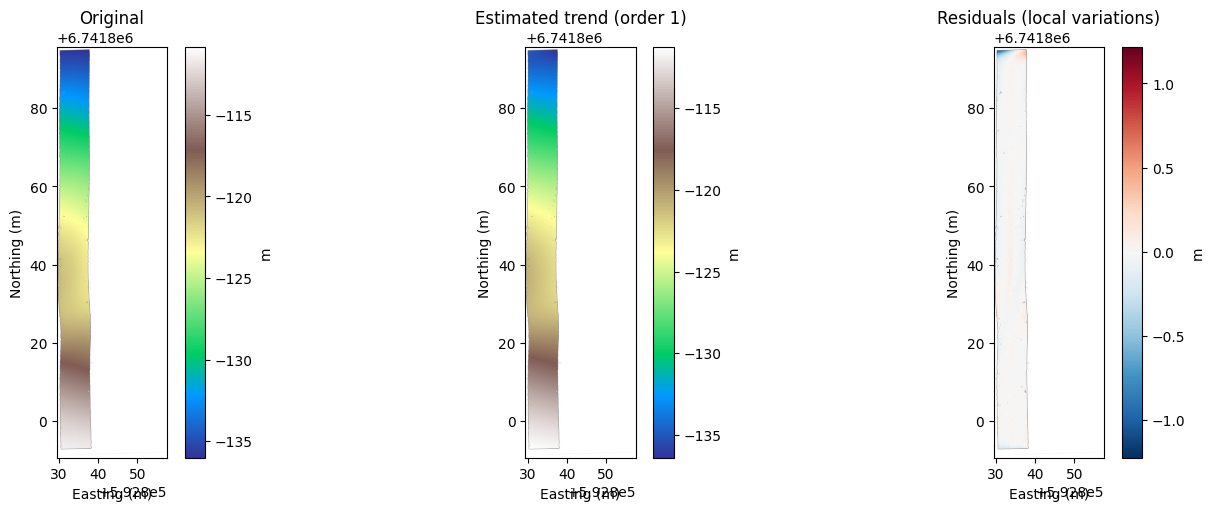

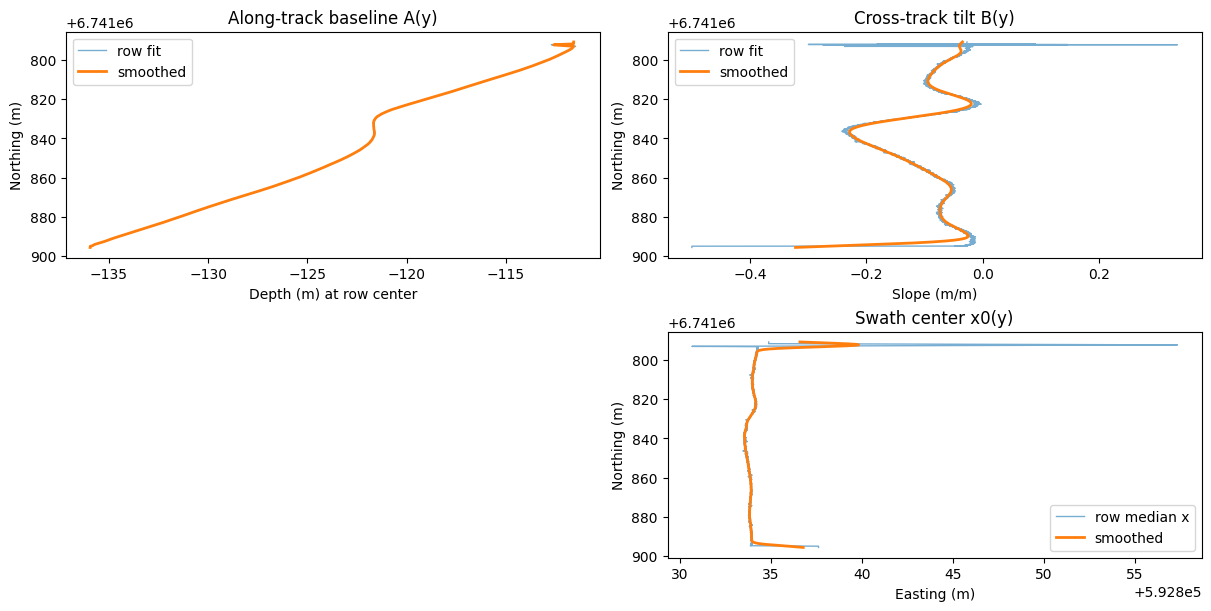

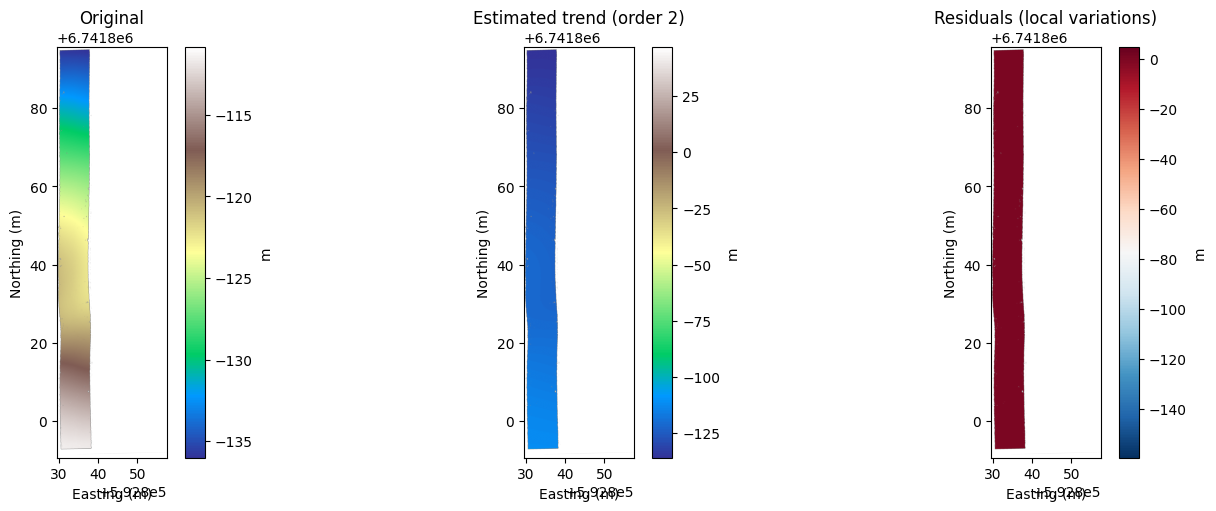

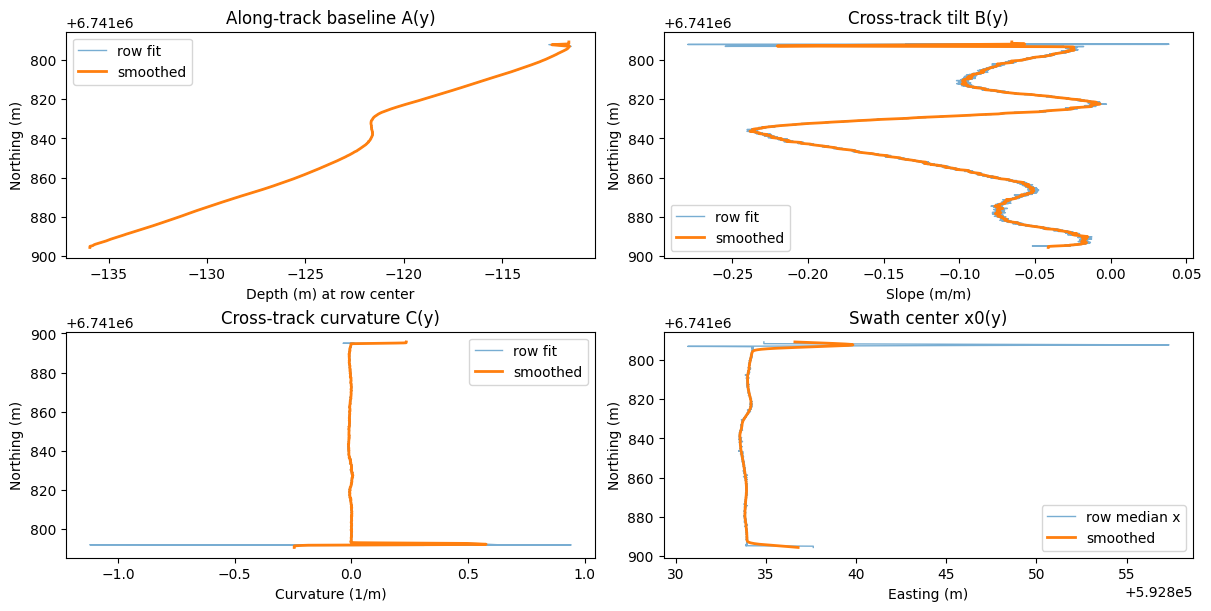

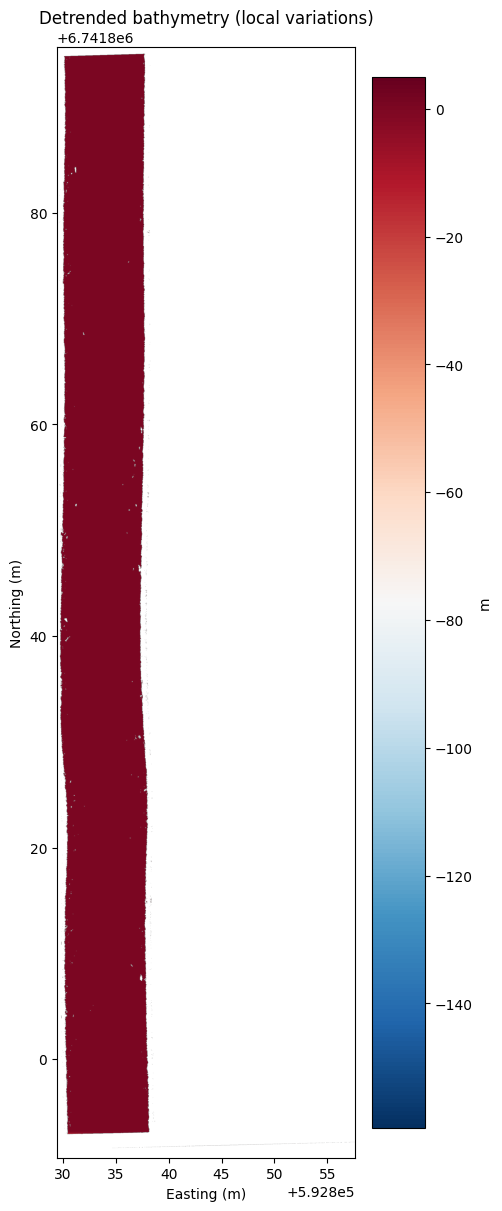

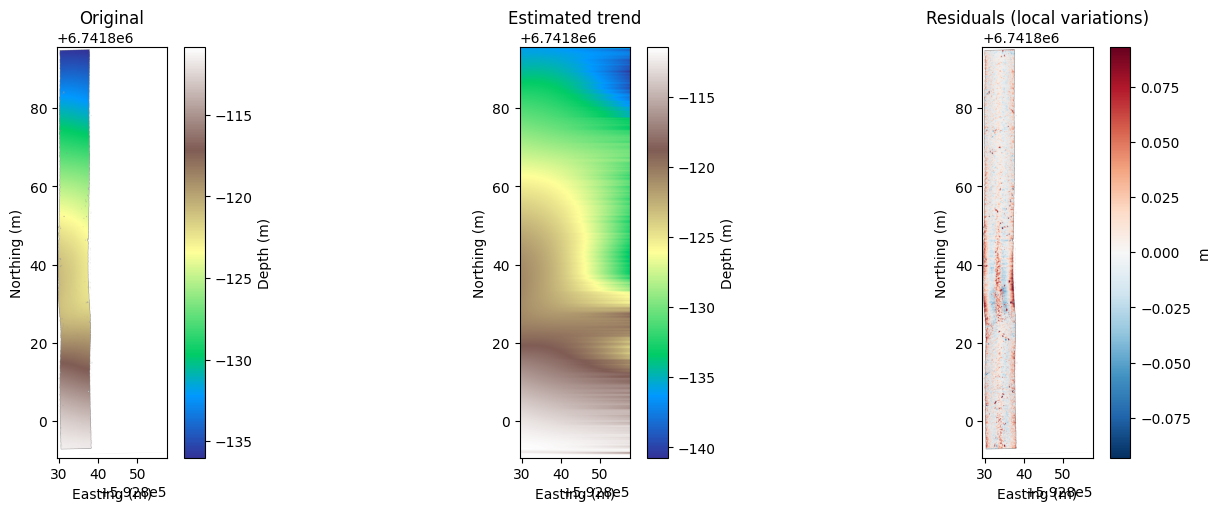

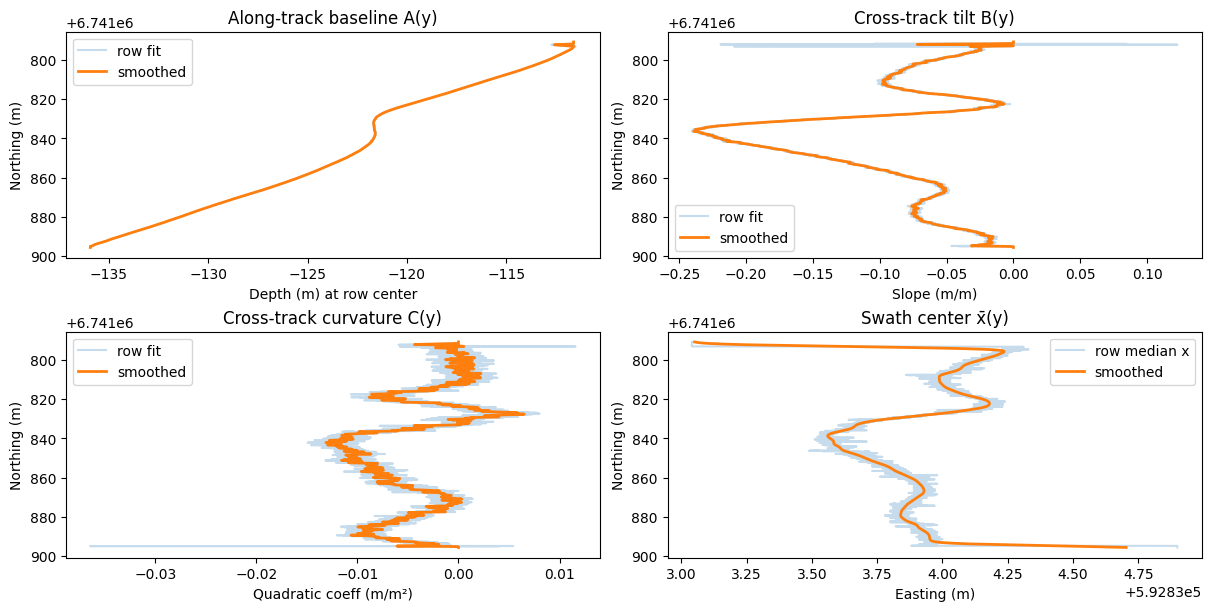

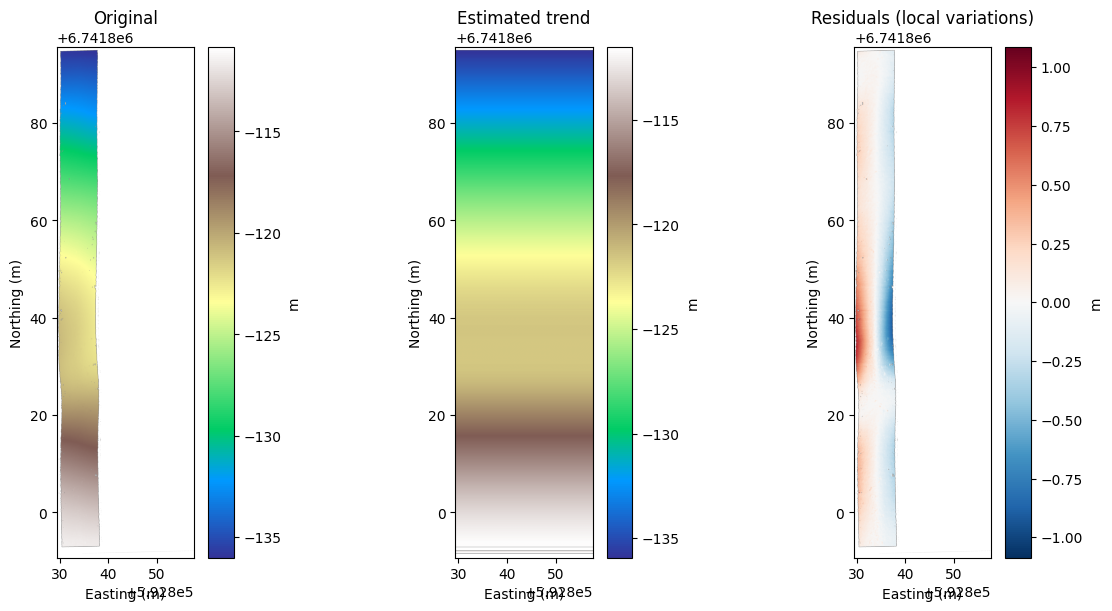

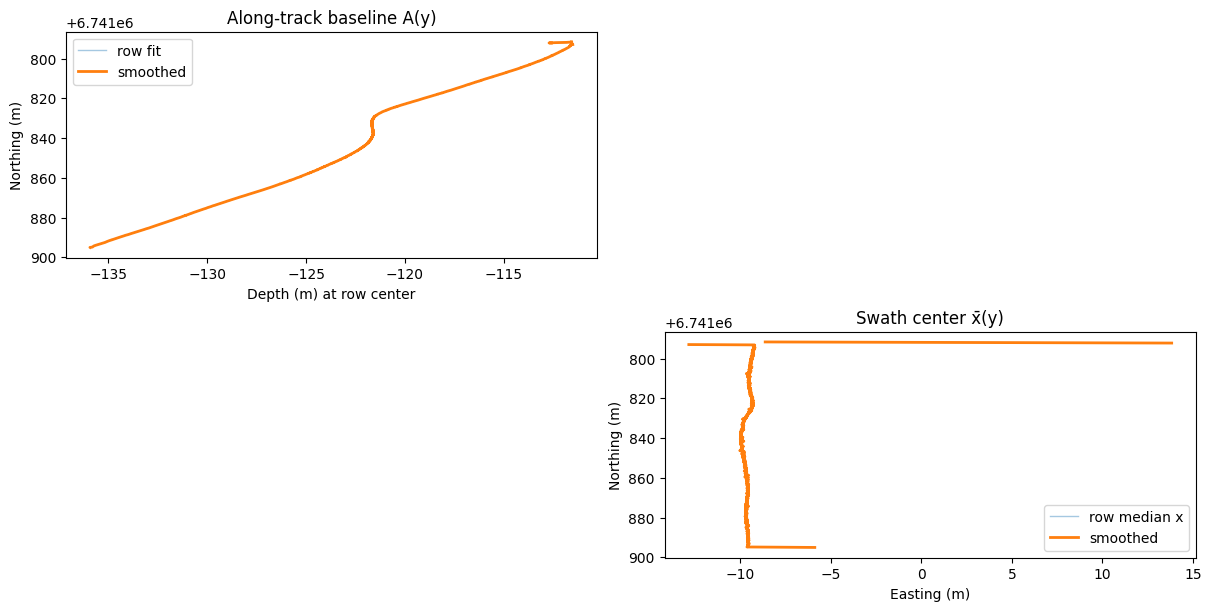

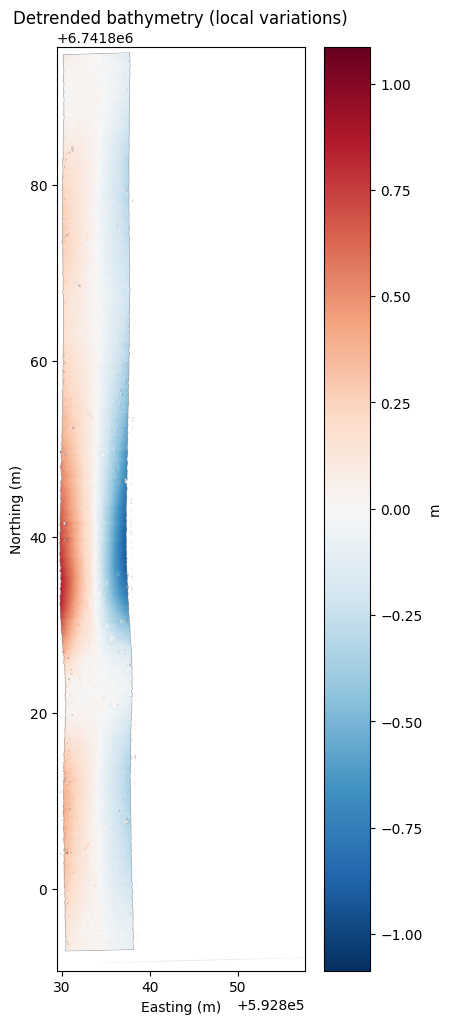

In [18]:
tif = r"E:\mjosa_new\DTM\geotiff_2.tif"

mb = MBESDetrender(tif).load()

# Start simple: baseline only, NO smoothing anywhere, use entire swath
mb.detrend(
    order_x=0,
    smooth_baseline_m=0,
    smooth_tilt_m=0,
    smooth_center_m=0,
    central_frac=1.0,
    robust=True,
    debug=True,
)

mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap(figsize=(5, 12))

# Then incrementally add knobs, for example:
# mb.detrend(order_x=1,
#            smooth_baseline_m=0.10,   # meters along-track; 0.10 m ≈ 5 px if dy=0.02 m
#            smooth_tilt_m=0.10,
#            smooth_center_m=0.20,
#            central_frac=0.8,
#            robust=True,
#            debug=True)
# mb.plot_triptych(); mb.plot_components(); mb.plot_residual_heatmap(figsize=(5, 12))

[detrend] order_x=0
[detrend] sigma_rows: A=5.00, B/C=1000.00, x0=50.00
[detrend] central_frac=0.8


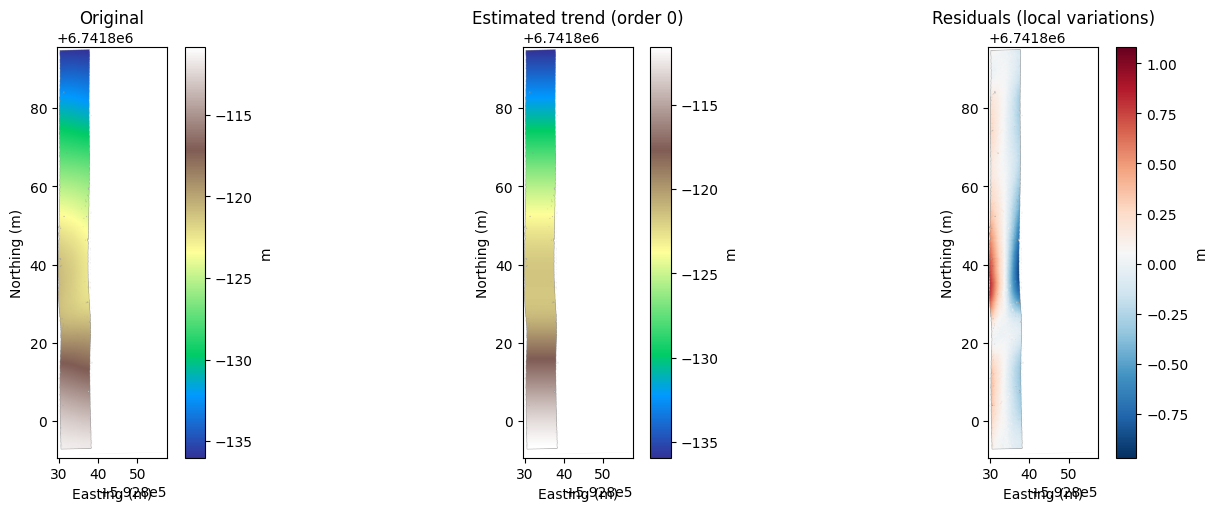

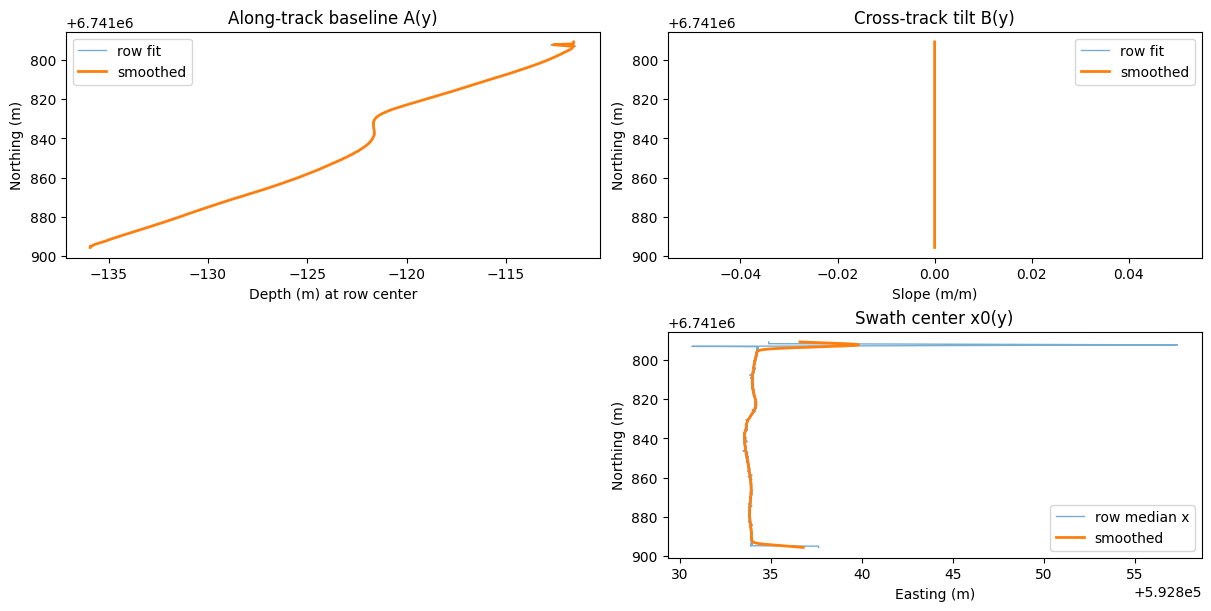

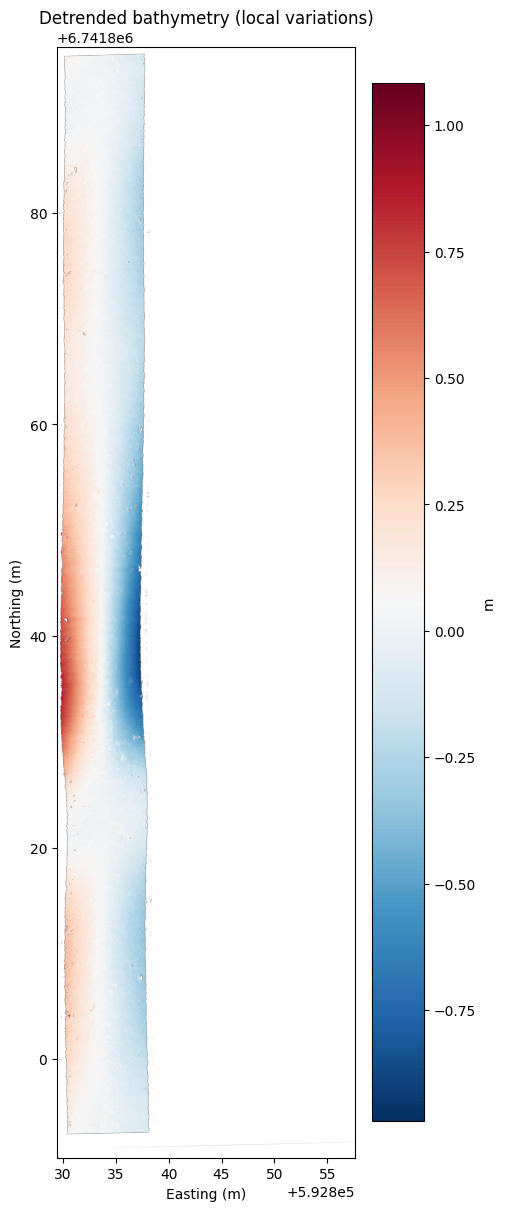

In [8]:
tif = r"E:\mjosa_new\DTM\geotiff_2.tif"

mb = MBESDetrender(tif).load()

# Start simple: baseline only, NO smoothing anywhere, use entire swath
mb.detrend(
    order_x=0,
    smooth_baseline_m=0.1,
    smooth_tilt_m=20,
    smooth_center_m=1,
    central_frac=0.8,
    robust=True,
    debug=True,
)

mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap(figsize=(5, 12))

# Then incrementally add knobs, for example:
# mb.detrend(order_x=1,
#            smooth_baseline_m=0.10,   # meters along-track; 0.10 m ≈ 5 px if dy=0.02 m
#            smooth_tilt_m=0.10,
#            smooth_center_m=0.20,
#            central_frac=0.8,
#            robust=True,
#            debug=True)
# mb.plot_triptych(); mb.plot_components(); mb.plot_residual_heatmap(figsize=(5, 12))

In [7]:
# --- MBES detrending (baseline/tilt/curvature) -------------------------------
# Requirements: rasterio, numpy, scipy
import numpy as np
import rasterio
from rasterio.transform import Affine
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt


def _sigma_rows_from_meters(meters, pixel_size_y):
    """Return Gaussian sigma in ROWS. If meters<=0 or None -> 0 (OFF)."""
    if meters is None or meters <= 0:
        return 0.0
    # sigma in rows (Gaussian std, not window length)
    return float(meters / abs(pixel_size_y))


def _smooth_or_copy(v, sigma_rows):
    """Gaussian smooth (sigma_rows); if <=0, return a COPY of v (OFF)."""
    if sigma_rows is None or sigma_rows <= 0:
        return v.copy()
    return gaussian_filter1d(v, sigma_rows, mode="nearest")


def _percentile_clip(x, lo=2.0, hi=98.0):
    """Return mask of values within lo..hi percentiles (robust outlier trim)."""
    if x.size < 5:  # nothing to clip
        return np.ones_like(x, dtype=bool)
    p_lo, p_hi = np.nanpercentile(x, [lo, hi])
    return (x >= p_lo) & (x <= p_hi)


class MBESDetrender:
    """
    Detrend a narrow MBES swath by fitting per-row cross-track polynomials:
        z(x,y) ≈ A(y) + B(y)*(x-x0(y)) + C(y)*(x-x0(y))^2
    Then smooth A,B,x0 along-track (y) with Gaussian kernels defined in meters.

    Parameters (in detrend()):
      order_x: 0 (baseline only), 1 (baseline + tilt), 2 (add curvature)
      smooth_baseline_m: Gaussian sigma [m] for A(y); 0/None = OFF
      smooth_tilt_m:     Gaussian sigma [m] for B(y) and C(y); 0/None = OFF
      smooth_center_m:   Gaussian sigma [m] for x0(y); 0/None = OFF
      central_frac:      fraction (0..1] of swath width used for fits around center
      robust:            if True, sigma-clip residuals inside each row fit
    """

    def __init__(self, tif_path):
        self.tif_path = tif_path
        # populated by load()
        self.data = None
        self.mask = None
        self.transform = None
        self.bounds = None
        self.res_x = None
        self.res_y = None
        self.extent = None  # (xmin, xmax, ymin, ymax)
        # populated by detrend()
        self.order_x = None
        self.A = self.B = self.C = self.x0 = None  # raw per-row fits
        self.A_s = self.B_s = self.C_s = self.x0_s = None  # smoothed along-track
        self.residuals = None
        self.trend = None

    # --------------------------- I/O -----------------------------------------
    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype("float64")
            nodata = src.nodata
            self.transform = src.transform
            self.bounds = src.bounds
            self.crs = src.crs
        if nodata is None:
            # common MBES placeholder
            nodata = 9999
        z = np.where(np.isfinite(z) & (z != nodata), z, np.nan)
        self.data = z
        self.mask = np.isfinite(z)

        # pixel sizes (assuming north-up; works for typical GeoTIFFs)
        T: Affine = self.transform
        self.res_x = float(np.hypot(T.a, T.d))  # ~|a|
        self.res_y = float(np.hypot(T.b, T.e))  # ~|e|
        # image extent for plotting
        xmin, xmax = self.bounds.left, self.bounds.right
        ymin, ymax = self.bounds.bottom, self.bounds.top
        self.extent = (xmin, xmax, ymin, ymax)
        return self

    # ----------------------- core fitting per row ----------------------------
    def _fit_row(self, i, cols_all, central_frac, order_x, robust):
        """
        Fit polynomial in x_rel for row i.
        Returns (A_i, B_i, C_i, x0_i) where x0_i is median x of valid samples.
        Any coefficient that isn't needed at given order is 0.0.
        If not enough points, returns (nan, nan, nan, nan).
        """
        row = self.data[i, :]
        valid_j = np.where(np.isfinite(row))[0]
        if valid_j.size < 4:  # too sparse to fit anything reliable
            return np.nan, np.nan, np.nan, np.nan

        # x coordinate for this row (center of each pixel)
        # Affine: x = c + a*(j+0.5) + b*(i+0.5)
        T = self.transform
        x_row = T.c + T.a * (cols_all + 0.5) + T.b * (i + 0.5)
        x_valid = x_row[valid_j]
        z_valid = row[valid_j]

        # swath center x0 at this row = median of valid x
        x0_i = np.nanmedian(x_valid)

        # Take central fraction of swath around x0
        cf = central_frac
        if (cf is None) or (cf <= 0) or (cf > 1):
            cf = 1.0
        half_width = 0.5 * cf * (np.nanmax(x_valid) - np.nanmin(x_valid))
        sel = (x_valid >= (x0_i - half_width)) & (x_valid <= (x0_i + half_width))
        x_c = x_valid[sel]
        z_c = z_valid[sel]

        if x_c.size < max(
            6, 3 * (order_x + 1)
        ):  # not enough points for the chosen order
            return np.nan, np.nan, np.nan, x0_i

        # center x to reduce covariance
        x_rel = x_c - x0_i

        # robust trimming (simple, fast): clip z range to 2..98 percentile of residuals iteratively
        if robust and order_x >= 1:
            for _ in range(2):  # two passes are usually enough
                coeff = np.polyfit(x_rel, z_c, deg=order_x)  # highest -> lowest
                z_fit = np.polyval(coeff, x_rel)
                r = z_c - z_fit
                keep = _percentile_clip(r, 2.0, 98.0)
                x_rel, z_c = x_rel[keep], z_c[keep]
                if x_rel.size < max(6, 3 * (order_x + 1)):
                    break

        # final fit
        coeff = np.polyfit(x_rel, z_c, deg=order_x)
        # coeff is [C, B, A] if order=2; [B, A] if order=1; [A] if order=0
        if order_x == 0:
            A_i, B_i, C_i = float(coeff[-1]), 0.0, 0.0
        elif order_x == 1:
            B_i, A_i = float(coeff[0]), float(coeff[1])
            C_i = 0.0
        else:
            C_i, B_i, A_i = float(coeff[0]), float(coeff[1]), float(coeff[2])

        return A_i, B_i, C_i, x0_i

    # ----------------------------- detrend -----------------------------------
    def detrend(
        self,
        order_x=1,
        smooth_baseline_m=0.2,
        smooth_tilt_m=0.2,
        smooth_center_m=0.1,
        central_frac=0.9,
        robust=True,
        debug=False,
    ):
        """
        Compute A(y), B(y), C(y), x0(y); smooth them along-track; build trend & residuals.
        """
        assert self.data is not None, "Call .load() first."
        self.order_x = int(order_x)

        rows, cols = self.data.shape
        cols_all = np.arange(cols, dtype=np.float64)

        A = np.full(rows, np.nan, dtype=np.float64)
        B = np.full(rows, 0.0, dtype=np.float64)
        C = np.full(rows, 0.0, dtype=np.float64)
        x0 = np.full(rows, np.nan, dtype=np.float64)

        for i in range(rows):
            Ai, Bi, Ci, x0i = self._fit_row(
                i, cols_all, central_frac, self.order_x, robust
            )
            A[i], B[i], C[i], x0[i] = Ai, Bi, Ci, x0i

        # Interpolate any NaN rows (linear in y) before smoothing
        def _interp_nans(v):
            idx = np.arange(v.size)
            good = np.isfinite(v)
            if good.sum() < 2:
                return v  # not enough info to fill
            v_filled = v.copy()
            v_filled[~good] = np.interp(idx[~good], idx[good], v[good])
            return v_filled

        A = _interp_nans(A)
        x0 = _interp_nans(x0)
        if self.order_x >= 1:
            B = _interp_nans(B)
        if self.order_x >= 2:
            C = _interp_nans(C)

        # Convert smoothing meters → Gaussian sigma (in rows)
        sA = _sigma_rows_from_meters(smooth_baseline_m, self.res_y)
        sBX = _sigma_rows_from_meters(smooth_tilt_m, self.res_y)
        sX0 = _sigma_rows_from_meters(smooth_center_m, self.res_y)

        # Apply smoothing (OFF if sigma<=0)
        A_s = _smooth_or_copy(A, sA)
        x0_s = _smooth_or_copy(x0, sX0)
        if self.order_x >= 1:
            B_s = _smooth_or_copy(B, sBX)
        else:
            B_s = np.zeros_like(B)
        if self.order_x >= 2:
            C_s = _smooth_or_copy(C, sBX)  # use same kernel for curvature
        else:
            C_s = np.zeros_like(C)

        # Build trend & residuals row-by-row (memory friendly)
        trend = np.full_like(self.data, np.nan, dtype=np.float64)
        residuals = np.full_like(self.data, np.nan, dtype=np.float64)

        T = self.transform
        for i in range(rows):
            valid_j = np.where(np.isfinite(self.data[i, :]))[0]
            if valid_j.size == 0:
                continue
            x_row = T.c + T.a * (cols_all + 0.5) + T.b * (i + 0.5)
            x_rel = x_row[valid_j] - x0_s[i]
            if self.order_x == 0:
                z_fit = A_s[i] * np.ones_like(x_rel)
            elif self.order_x == 1:
                z_fit = A_s[i] + B_s[i] * x_rel
            else:
                z_fit = A_s[i] + B_s[i] * x_rel + C_s[i] * (x_rel**2)

            trend[i, valid_j] = z_fit
            residuals[i, valid_j] = self.data[i, valid_j] - z_fit

        # store
        self.A, self.B, self.C, self.x0 = A, B, C, x0
        self.A_s, self.B_s, self.C_s, self.x0_s = A_s, B_s, C_s, x0_s
        self.trend = trend
        self.residuals = residuals

        if debug:
            print(f"[detrend] order_x={self.order_x}")
            print(f"[detrend] sigma_rows: A={sA:.2f}, B/C={sBX:.2f}, x0={sX0:.2f}")
            print(
                f"[detrend] central_frac={central_frac if (central_frac and central_frac>0) else 1.0}"
            )

        return self

    # --------------------------- plotting ------------------------------------
    def _xy_axes(self):
        xmin, xmax, ymin, ymax = self.extent
        return xmin, xmax, ymin, ymax

    def plot_triptych(self, vmin=None, vmax=None, cmap="terrain"):
        assert (
            self.data is not None
            and self.trend is not None
            and self.residuals is not None
        ), "Run detrend() first."
        fig, axs = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)

        def im(ax, A, title, cmap=cmap, vmin=None, vmax=None):
            xmin, xmax, ymin, ymax = self._xy_axes()
            h = ax.imshow(
                A,
                extent=(xmin, xmax, ymin, ymax),
                origin="upper",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                aspect="equal",
            )
            ax.set_title(title)
            ax.set_xlabel("Easting (m)")
            ax.set_ylabel("Northing (m)")
            plt.colorbar(h, ax=ax, label="m")

        im(axs[0], self.data, "Original", cmap="terrain", vmin=vmin, vmax=vmax)
        im(
            axs[1],
            self.trend,
            f"Estimated trend (order {self.order_x})",
            cmap="terrain",
            vmin=vmin,
            vmax=vmax,
        )
        im(axs[2], self.residuals, "Residuals (local variations)", cmap="RdBu_r")
        plt.show()

    def plot_residual_heatmap(self, figsize=(5, 12), clim=None):
        assert self.residuals is not None, "Run detrend() first."
        fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
        xmin, xmax, ymin, ymax = self._xy_axes()
        h = ax.imshow(
            self.residuals,
            extent=(xmin, xmax, ymin, ymax),
            origin="upper",
            cmap="RdBu_r",
        )
        if clim:
            h.set_clim(*clim)
        ax.set_title("Detrended bathymetry (local variations)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.colorbar(h, ax=ax, label="m")
        plt.show()

    def plot_components(self, figsize=(12, 6)):
        assert self.A_s is not None, "Run detrend() first."
        rows = self.data.shape[0]
        # y-axis for row centers
        T = self.transform
        y_rows = T.f + T.e * (np.arange(rows) + 0.5) + T.d * (0.5)

        fig, ax = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)

        # A(y)
        ax0 = ax[0, 0]
        ax0.plot(self.A, y_rows, lw=1, alpha=0.6, label="row fit")
        ax0.plot(self.A_s, y_rows, lw=2, label="smoothed")
        ax0.invert_yaxis()
        ax0.set_title("Along-track baseline A(y)")
        ax0.set_xlabel("Depth (m) at row center")
        ax0.set_ylabel("Northing (m)")
        ax0.legend()

        # B(y)
        ax1 = ax[0, 1]
        ax1.plot(self.B, y_rows, lw=1, alpha=0.6, label="row fit")
        ax1.plot(self.B_s, y_rows, lw=2, label="smoothed")
        ax1.invert_yaxis()
        ax1.set_title("Cross-track tilt B(y)")
        ax1.set_xlabel("Slope (m/m)")
        ax1.set_ylabel("Northing (m)")
        ax1.legend()

        # C(y)
        ax2 = ax[1, 0]
        if self.order_x >= 2:
            ax2.plot(self.C, y_rows, lw=1, alpha=0.6, label="row fit")
            ax2.plot(self.C_s, y_rows, lw=2, label="smoothed")
            ax2.set_title("Cross-track curvature C(y)")
            ax2.set_xlabel("Curvature (1/m)")
            ax2.set_ylabel("Northing (m)")
            ax2.legend()
        else:
            ax2.axis("off")

        # x0(y)
        ax3 = ax[1, 1]
        ax3.plot(self.x0, y_rows, lw=1, alpha=0.6, label="row median x")
        ax3.plot(self.x0_s, y_rows, lw=2, label="smoothed")
        ax3.invert_yaxis()
        ax3.set_title("Swath center x0(y)")
        ax3.set_xlabel("Easting (m)")
        ax3.set_ylabel("Northing (m)")
        ax3.legend()

        plt.show()

[detrend] order_x=0
[detrend] sigma_rows: A=5.00, B/C=5.00, x0=0.00
[detrend] central_frac=1.0


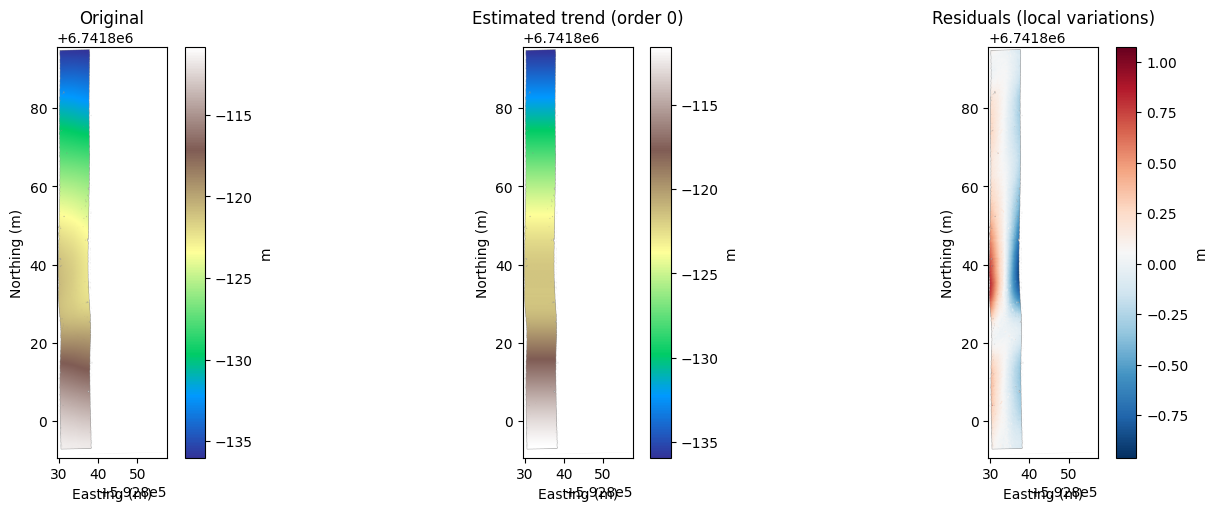

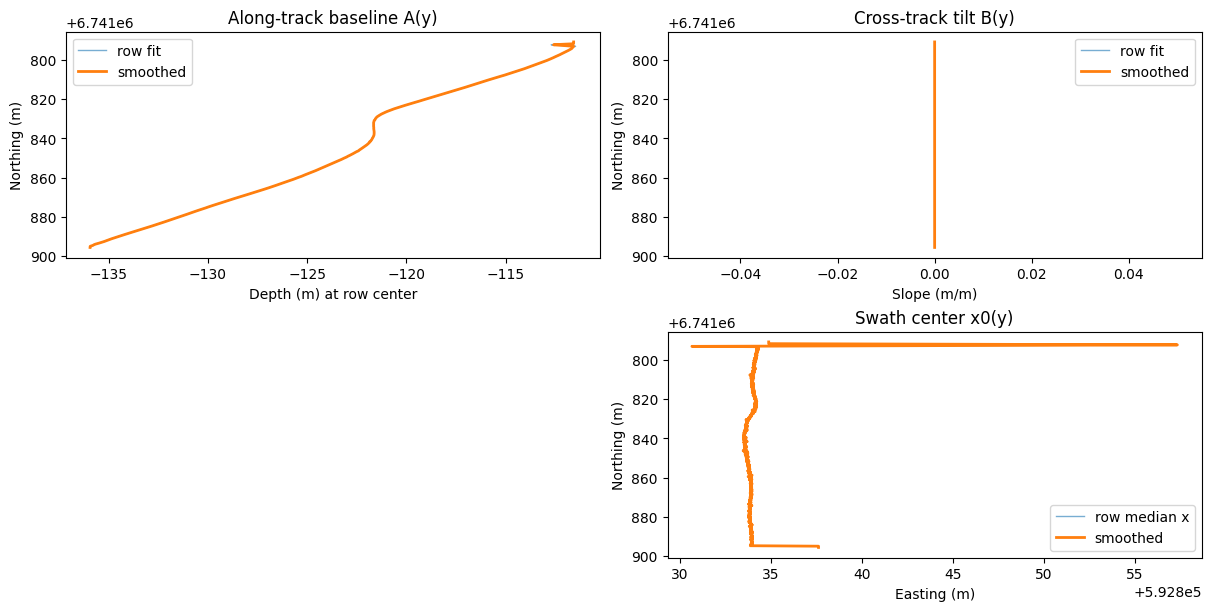

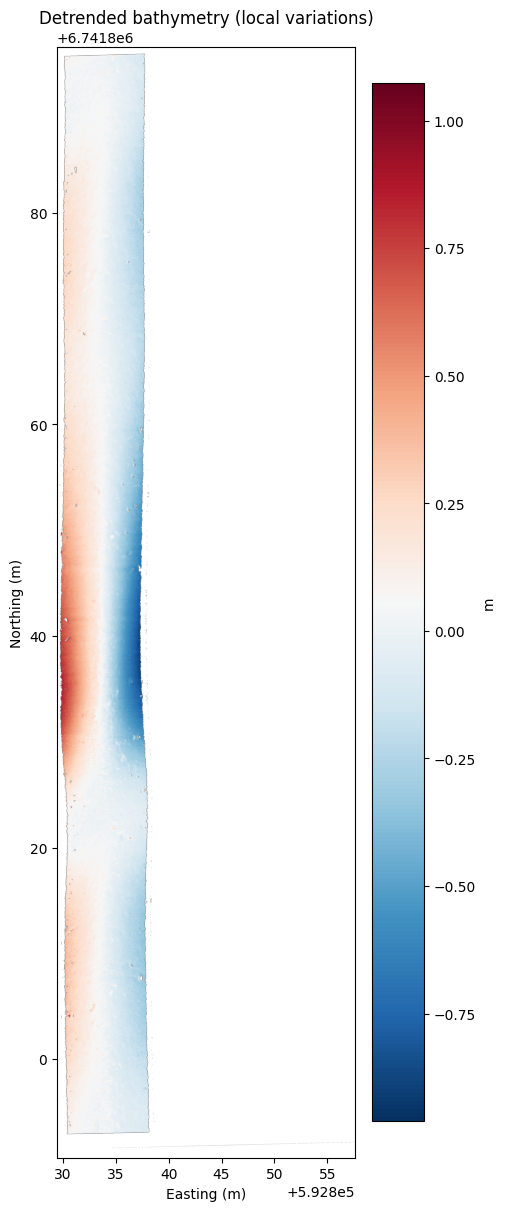

In [26]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# 1) Baseline-only, no smoothing (everything OFF)
mb.detrend(
    order_x=0,
    smooth_baseline_m=0.1,  # OFF
    smooth_tilt_m=0.1,  # OFF (unused for order_x=0)
    smooth_center_m=0,  # OFF
    central_frac=1.0,  # use full swath
    robust=True,
    debug=True,
)
mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap((5, 12))

[detrend] order_x=2
[detrend] sigma_rows: A=5.00, B/C=50.00, x0=50.00
[detrend] central_frac=1.0


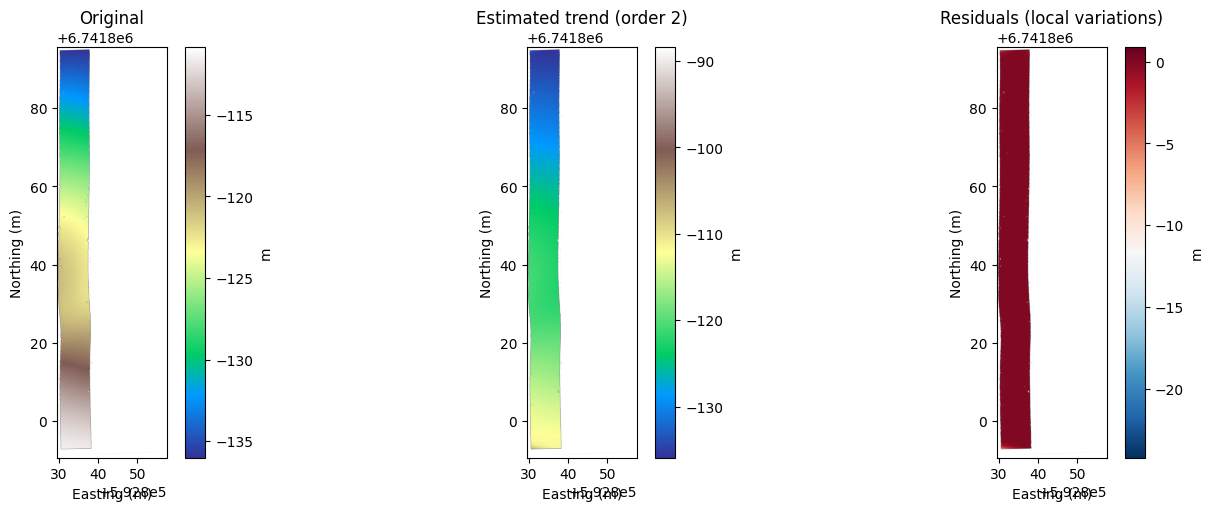

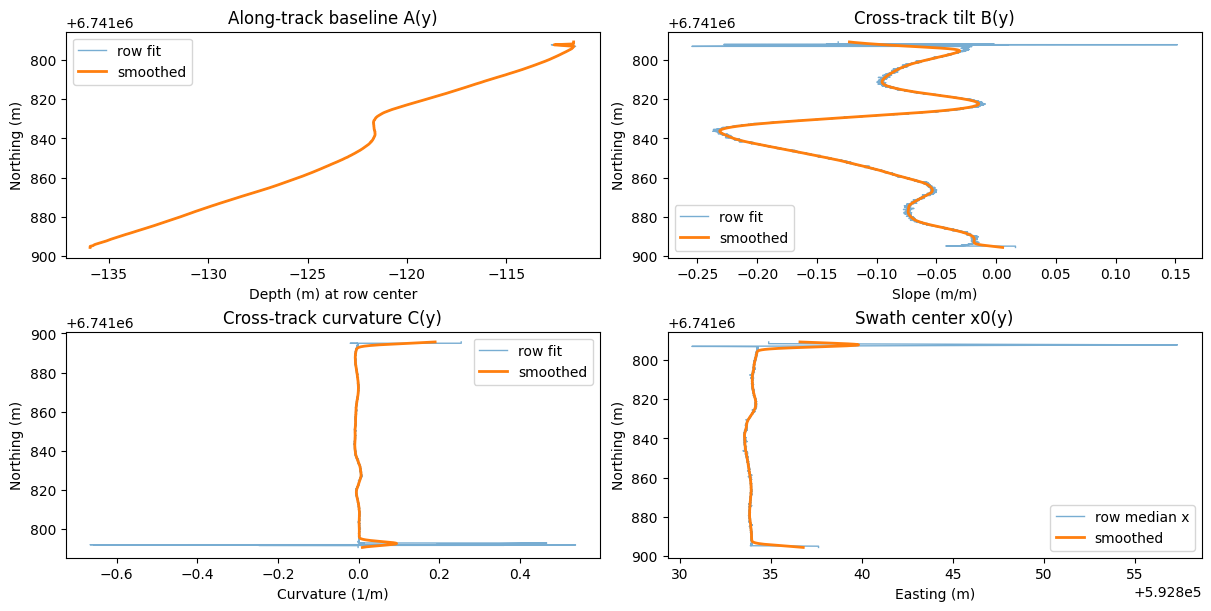

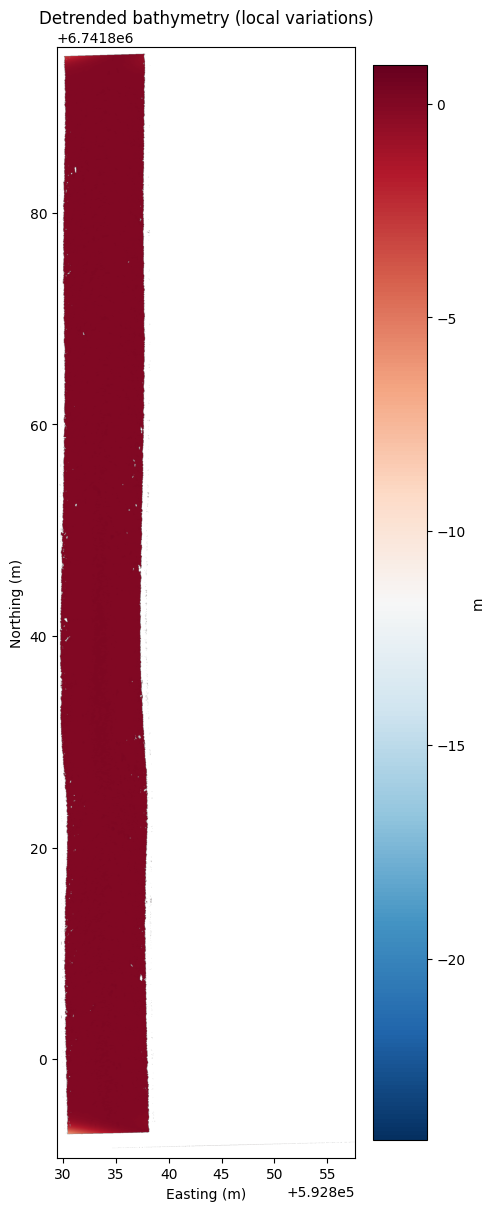

In [4]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# 1) Baseline-only, no smoothing (everything OFF)
mb.detrend(
    order_x=2,
    smooth_baseline_m=0.1,  # OFF
    smooth_tilt_m=1,  # OFF (unused for order_x=0)
    smooth_center_m=1,  # OFF
    central_frac=1.0,  # use full swath
    robust=True,
    debug=True,
)
mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap((5, 12))

[detrend] order_x=2
[detrend] sigma_rows: A=50.00, B/C=50.00, x0=50.00
[detrend] central_frac=0.8


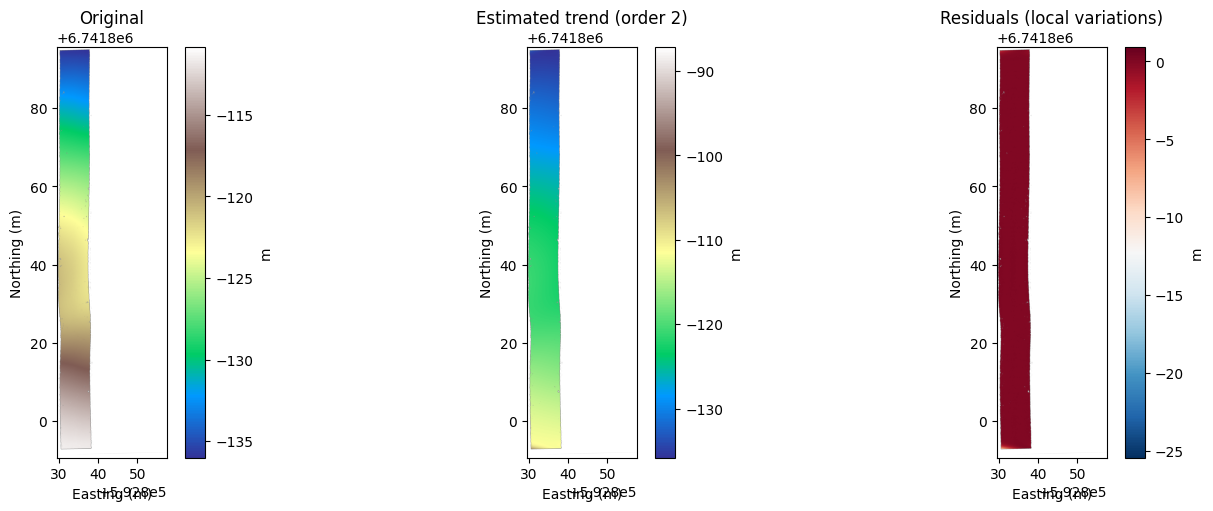

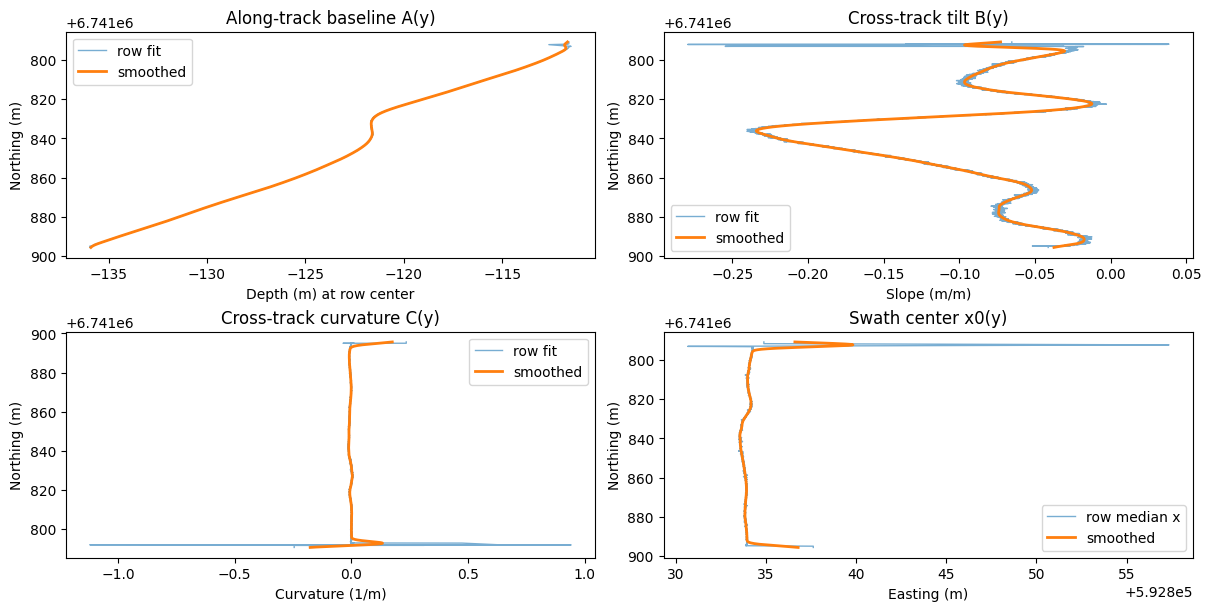

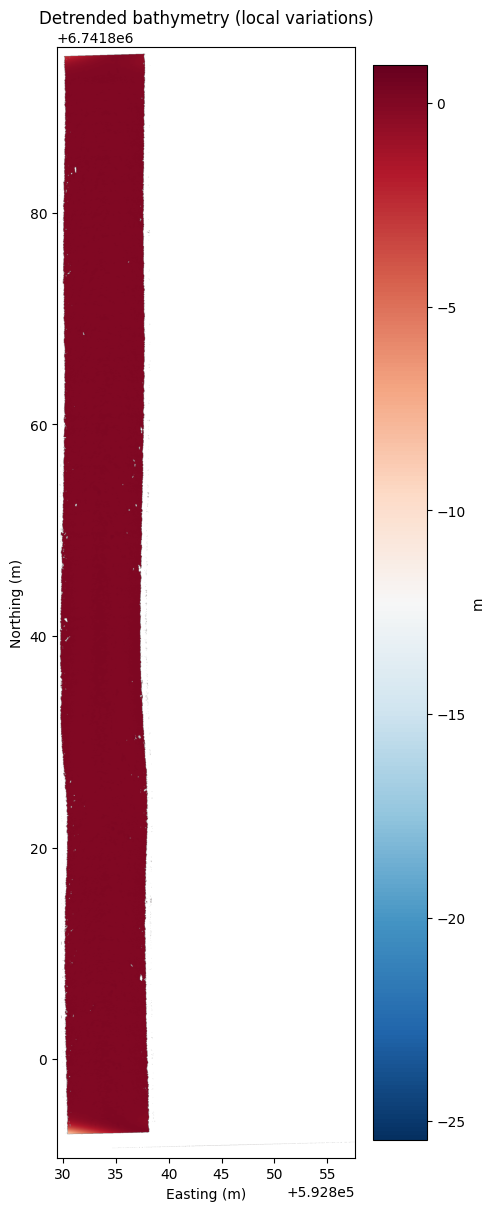

In [10]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# 1) Baseline-only, no smoothing (everything OFF)
mb.detrend(
    order_x=2,
    smooth_baseline_m=1,  # OFF
    smooth_tilt_m=1,  # OFF (unused for order_x=0)
    smooth_center_m=1,  # OFF
    central_frac=0.8,  # use full swath
    robust=True,
    debug=True,
)
mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap((5, 12))

In [12]:
tif = r"E:\mjosa_new\DTM\geotiff_2.tif"
%matplotlib qt
mb = MBESDetrender(tif).load()

# Start simple: baseline only, NO smoothing anywhere, use entire swath
mb.detrend(
    order_x=1,
    smooth_baseline_m=0.1,
    smooth_tilt_m=2,
    smooth_center_m=1,
    central_frac=0.8,
    robust=True,
    debug=True,
)

mb.plot_triptych()
mb.plot_components()
mb.plot_residual_heatmap(figsize=(5, 12))

# Then incrementally add knobs, for example:
# mb.detrend(order_x=1,
#            smooth_baseline_m=0.10,   # meters along-track; 0.10 m ≈ 5 px if dy=0.02 m
#            smooth_tilt_m=0.10,
#            smooth_center_m=0.20,
#            central_frac=0.8,
#            robust=True,
#            debug=True)
# mb.plot_triptych(); mb.plot_components(); mb.plot_residual_heatmap(figsize=(5, 12))

[detrend] order_x=1
[detrend] sigma_rows: A=5.00, B/C=100.00, x0=50.00
[detrend] central_frac=0.8
